# Data Preprocess

## Read Data

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print("="*70)
print("ENHANCED DATA PREPROCESSING WITH NaN HANDLING")
print("="*70)

rainfall_path = 'BUHI_Rainfall-Data.csv'
riverlevel_path = 'BUHI_Riverlevel-Data.csv'

rainfall_df = pd.read_csv(rainfall_path, na_values='NaN')
riverlevel_df = pd.read_csv(riverlevel_path, na_values='NaN')

print("✓ Data loaded")
print(f"  Rainfall shape: {rainfall_df.shape}")
print(f"  River level shape: {riverlevel_df.shape}")

ENHANCED DATA PREPROCESSING WITH NaN HANDLING
✓ Data loaded
  Rainfall shape: (9008, 2)
  River level shape: (9008, 2)


## Parse DateTime and Sort

In [4]:
# Strip whitespace from column names
rainfall_df.columns = rainfall_df.columns.str.strip()
riverlevel_df.columns = riverlevel_df.columns.str.strip()

# If DateTime is already the index (from a previous run), reset it back to a column
if 'DateTime' not in rainfall_df.columns:
    rainfall_df = rainfall_df.reset_index()
    if 'index' in rainfall_df.columns:
        rainfall_df = rainfall_df.rename(columns={'index': 'DateTime'})
if 'DateTime' not in riverlevel_df.columns:
    riverlevel_df = riverlevel_df.reset_index()
    if 'index' in riverlevel_df.columns:
        riverlevel_df = riverlevel_df.rename(columns={'index': 'DateTime'})

# Parse DateTime, coercing invalid entries (e.g., "0000-00-00 00") to NaT
rainfall_df['DateTime'] = pd.to_datetime(rainfall_df['DateTime'], errors='coerce')
riverlevel_df['DateTime'] = pd.to_datetime(riverlevel_df['DateTime'], errors='coerce')

# Drop rows with invalid datetimes
rain_invalid = rainfall_df['DateTime'].isna().sum()
river_invalid = riverlevel_df['DateTime'].isna().sum()
print(f"⚠️  Dropped {rain_invalid} invalid datetime rows from rainfall")
print(f"⚠️  Dropped {river_invalid} invalid datetime rows from river level")

rainfall_df = rainfall_df.dropna(subset=['DateTime'])
riverlevel_df = riverlevel_df.dropna(subset=['DateTime'])

rainfall_df = rainfall_df.set_index('DateTime').sort_index()
riverlevel_df = riverlevel_df.set_index('DateTime').sort_index()

⚠️  Dropped 0 invalid datetime rows from rainfall
⚠️  Dropped 0 invalid datetime rows from river level


## NaN Handling

In [5]:
print("\n" + "="*70)
print("ANALYZING NaN VALUES")
print("="*70)

print("\nRainfall NaN percentage per station:")
rain_nan_pct = (rainfall_df.isnull().sum() / len(rainfall_df)) * 100
for col, pct in rain_nan_pct.items():
    print(f"  {col}: {pct:.1f}%")

print("\nRiver Level NaN percentage per station:")
river_nan_pct = (riverlevel_df.isnull().sum() / len(riverlevel_df)) * 100
for col, pct in river_nan_pct.items():
    print(f"  {col}: {pct:.1f}%")

print("\n" + "="*70)
print("REMOVING STATIONS WITH >80% NaN")
print("="*70)

rain_valid_cols = rain_nan_pct[rain_nan_pct < 80].index.tolist()
river_valid_cols = river_nan_pct[river_nan_pct < 80].index.tolist()

print(f"\nRainfall stations kept: {len(rain_valid_cols)}/{len(rainfall_df.columns)}")
print(f"Removed: {set(rainfall_df.columns) - set(rain_valid_cols)}")

print(f"\nRiver level stations kept: {len(river_valid_cols)}/{len(riverlevel_df.columns)}")
print(f"Removed: {set(riverlevel_df.columns) - set(river_valid_cols)}")

rainfall_df = rainfall_df[rain_valid_cols]
riverlevel_df = riverlevel_df[river_valid_cols]


ANALYZING NaN VALUES

Rainfall NaN percentage per station:
  Buhi: 1.6%

River Level NaN percentage per station:
  Buhi: 0.0%

REMOVING STATIONS WITH >80% NaN

Rainfall stations kept: 1/1
Removed: set()

River level stations kept: 1/1
Removed: set()


## Generate Time Index

In [6]:
print("\n" + "="*70)
print("GENERATING TIME INDEX")
print("="*70)

full_index = pd.date_range(
    start=min(rainfall_df.index.min(), riverlevel_df.index.min()),
    end=max(rainfall_df.index.max(), riverlevel_df.index.max()),
    freq='h'
)

rainfall_df = rainfall_df.reindex(full_index)
riverlevel_df = riverlevel_df.reindex(full_index)

rainfall_df = rainfall_df.ffill().bfill().fillna(0)
riverlevel_df = riverlevel_df.ffill().bfill().fillna(0)

print(f"✓ Time index generated")
print(f"  Date range: {full_index.min()} to {full_index.max()}")
print(f"  Total hours: {len(full_index)}")


GENERATING TIME INDEX
✓ Time index generated
  Date range: 2024-10-19 01:00:00 to 2025-10-29 08:00:00
  Total hours: 9008


## Normalize

In [7]:
# Normalize
print("\n" + "="*70)
print("NORMALIZING DATA")
print("="*70)

rain_scaler = MinMaxScaler()
river_scaler = MinMaxScaler()

rainfall_norm = pd.DataFrame(
    rain_scaler.fit_transform(rainfall_df),
    index=rainfall_df.index,
    columns=rainfall_df.columns
)

riverlevel_norm = pd.DataFrame(
    river_scaler.fit_transform(riverlevel_df),
    index=riverlevel_df.index,
    columns=riverlevel_df.columns
)

print("✓ Data normalized")


NORMALIZING DATA
✓ Data normalized


## Nan Check

In [8]:
# CRITICAL: Final NaN check
print("\n" + "="*70)
print("FINAL NaN CHECK")
print("="*70)

final_rain_nan = rainfall_norm.isnull().sum().sum()
final_river_nan = riverlevel_norm.isnull().sum().sum()

print(f"Rainfall NaN count: {final_rain_nan}")
print(f"River level NaN count: {final_river_nan}")

if final_rain_nan > 0:
    print("⚠️  Forcing rainfall NaN to 0...")
    rainfall_norm = rainfall_norm.fillna(0)

if final_river_nan > 0:
    print("⚠️  Forcing river level NaN to 0...")
    riverlevel_norm = riverlevel_norm.fillna(0)

# Verify no infinities
if np.any(np.isinf(rainfall_norm.values)):
    print("⚠️  Found infinities in rainfall, replacing with 0...")
    rainfall_norm = rainfall_norm.replace([np.inf, -np.inf], 0)

if np.any(np.isinf(riverlevel_norm.values)):
    print("⚠️  Found infinities in river level, replacing with 0...")
    riverlevel_norm = riverlevel_norm.replace([np.inf, -np.inf], 0)

print("\n✅ DATA IS CLEAN - NO NaN OR INFINITIES")


FINAL NaN CHECK
Rainfall NaN count: 0
River level NaN count: 98
⚠️  Forcing river level NaN to 0...

✅ DATA IS CLEAN - NO NaN OR INFINITIES


## Stats

In [9]:
print("\n" + "="*50)
print("RAINFALL NORMALIZED STATISTICS")
print("="*50)
print(rainfall_norm.describe())

print("\n" + "="*50)
print("RIVER LEVEL NORMALIZED STATISTICS")
print("="*50)
print(riverlevel_norm.describe())

print("\n" + "="*50)
print("NULL VALUES CHECK")
print("="*50)
print("Rainfall null values:")
print(rainfall_norm.isnull().sum())
print("\nRiver level null values:")
print(riverlevel_norm.isnull().sum())


RAINFALL NORMALIZED STATISTICS
              Buhi
count  9008.000000
mean      0.006453
std       0.035437
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000

RIVER LEVEL NORMALIZED STATISTICS
              Buhi
count  9008.000000
mean      0.143310
std       0.142630
min       0.000000
25%       0.000000
50%       0.123810
75%       0.253968
max       1.000000

NULL VALUES CHECK
Rainfall null values:
Buhi    0
dtype: int64

River level null values:
Buhi    0
dtype: int64


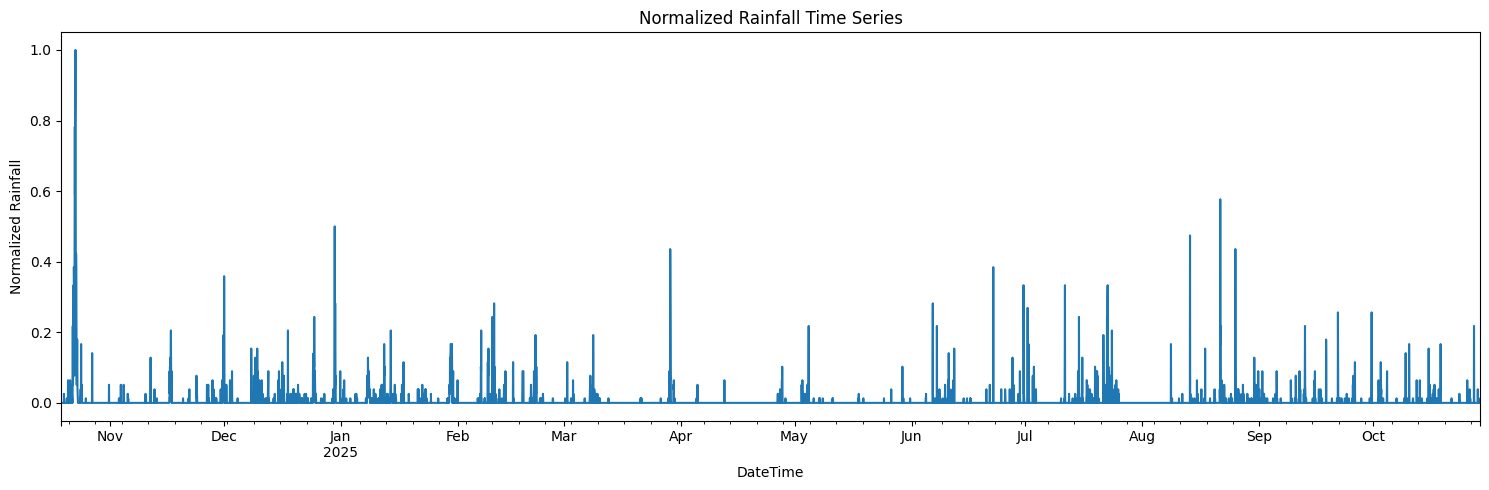

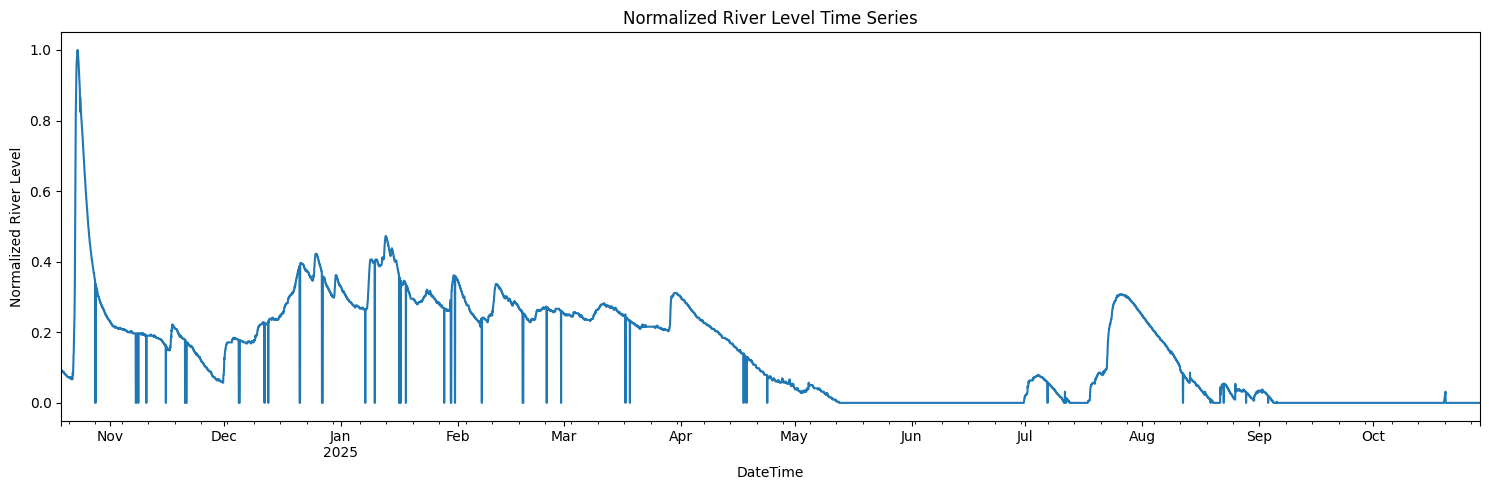


Final shapes: Rainfall (9008, 1), River Level (9008, 1)
Indices aligned: True

SAMPLE DATA (First 5 rows)

Rainfall:
                     Buhi
2024-10-19 01:00:00   0.0
2024-10-19 02:00:00   0.0
2024-10-19 03:00:00   0.0
2024-10-19 04:00:00   0.0
2024-10-19 05:00:00   0.0

River Level:
                         Buhi
2024-10-19 01:00:00  0.092063
2024-10-19 02:00:00  0.092063
2024-10-19 03:00:00  0.092063
2024-10-19 04:00:00  0.092063
2024-10-19 05:00:00  0.092063


In [10]:
import matplotlib.pyplot as plt

rainfall_norm.plot(figsize=(15,5), legend=False, title="Normalized Rainfall Time Series")
plt.ylabel("Normalized Rainfall")
plt.xlabel("DateTime")
plt.tight_layout()
plt.savefig('rainfall_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

riverlevel_norm.plot(figsize=(15,5), legend=False, title="Normalized River Level Time Series")
plt.ylabel("Normalized River Level")
plt.xlabel("DateTime")
plt.tight_layout()
plt.savefig('riverlevel_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal shapes: Rainfall {rainfall_norm.shape}, River Level {riverlevel_norm.shape}")
print(f"Indices aligned: {(rainfall_norm.index == riverlevel_norm.index).all()}")

print("\n" + "="*50)
print("SAMPLE DATA (First 5 rows)")
print("="*50)
print("\nRainfall:")
print(rainfall_norm.head())
print("\nRiver Level:")
print(riverlevel_norm.head())

In [11]:
print("\n" + "="*70)
print("SAVING CLEANED DATA")
print("="*70)

rainfall_norm.to_csv('rainfall_norm.csv')
riverlevel_norm.to_csv('riverlevel_norm.csv')

print("✓ Saved: rainfall_norm.csv")
print("✓ Saved: riverlevel_norm.csv")


SAVING CLEANED DATA
✓ Saved: rainfall_norm.csv
✓ Saved: riverlevel_norm.csv


## Station MetaData

In [12]:
# Load station metadata from CSV
print("\n" + "="*70)
print("LOADING STATION METADATA")
print("="*70)

station_meta_df = pd.read_csv('BUHI_station_metadata.csv')
print(f"✓ Station metadata loaded: {len(station_meta_df)} stations")
print(station_meta_df)

# Build coordinate lookup from CSV (columns: StationID, Longitude, Latitude)
all_station_coords = {}
for _, row in station_meta_df.iterrows():
    all_station_coords[row['StationID']] = (row['Longitude'], row['Latitude'])

# Get actual station names from cleaned data
rainfall_stations = rainfall_norm.columns.tolist()
riverlevel_stations = riverlevel_norm.columns.tolist()

# Create coordinate arrays
rainfall_coords = []
for station in rainfall_stations:
    if station in all_station_coords:
        lon, lat = all_station_coords[station]
        rainfall_coords.append([lon, lat])
    else:
        print(f"⚠️  Warning: No coordinates for rainfall station '{station}'")

riverlevel_coords = []
for station in riverlevel_stations:
    if station in all_station_coords:
        lon, lat = all_station_coords[station]
        riverlevel_coords.append([lon, lat])
    else:
        print(f"⚠️  Warning: No coordinates for river level station '{station}'")

rainfall_coords = np.array(rainfall_coords)
riverlevel_coords = np.array(riverlevel_coords)


LOADING STATION METADATA
✓ Station metadata loaded: 1 stations
  StationID  Longitude  Latitude
0      Buhi    123.509   13.4337


In [13]:
# Save
np.save('rainfall_coords.npy', rainfall_coords)
np.save('riverlevel_coords.npy', riverlevel_coords)

print(f"✓ Rainfall stations: {len(rainfall_stations)}")
print(f"✓ River level stations: {len(riverlevel_stations)}")
print("✓ Saved: rainfall_coords.npy")
print("✓ Saved: riverlevel_coords.npy")

# Summary
print("\n" + "="*70)
print("PREPROCESSING COMPLETE - DATA READY")
print("="*70)
print("\n✅ All NaN values handled")
print("✅ All infinities removed")
print("✅ Data properly normalized (0-1)")
print(f"✅ Rainfall: {rainfall_norm.shape[0]} hours × {rainfall_norm.shape[1]} stations")
print(f"✅ River level: {riverlevel_norm.shape[0]} hours × {riverlevel_norm.shape[1]} stations")
print("\n➡️  Next: Redo spatial gridding with cleaned data")
print("="*70)

✓ Rainfall stations: 1
✓ River level stations: 1
✓ Saved: rainfall_coords.npy
✓ Saved: riverlevel_coords.npy

PREPROCESSING COMPLETE - DATA READY

✅ All NaN values handled
✅ All infinities removed
✅ Data properly normalized (0-1)
✅ Rainfall: 9008 hours × 1 stations
✅ River level: 9008 hours × 1 stations

➡️  Next: Redo spatial gridding with cleaned data


# DEM Preprocess

## Dependencies

In [14]:
print("\n" + "="*50)
print("DEM PREPROCESSING WITH PROPER MASKING")
print("="*50)
import rasterio
import numpy as np
from scipy.ndimage import zoom

dem_path = 'BUHI_DTM.tif'

# Read DEM
with rasterio.open(dem_path) as src:
    dem_array = src.read(1)
    dem_meta = src.meta
    nodata_val = src.nodata if src.nodata is not None else -9999

print(f"✓ DEM loaded")
print(f"  DEM shape: {dem_array.shape}")
print(f"  NoData value: {nodata_val}")


DEM PREPROCESSING WITH PROPER MASKING
✓ DEM loaded
  DEM shape: (4065, 2907)
  NoData value: 0.0


## No Data Handling


✓ Valid basin pixels: 7942484 / 11816955
  Basin coverage: 67.2%


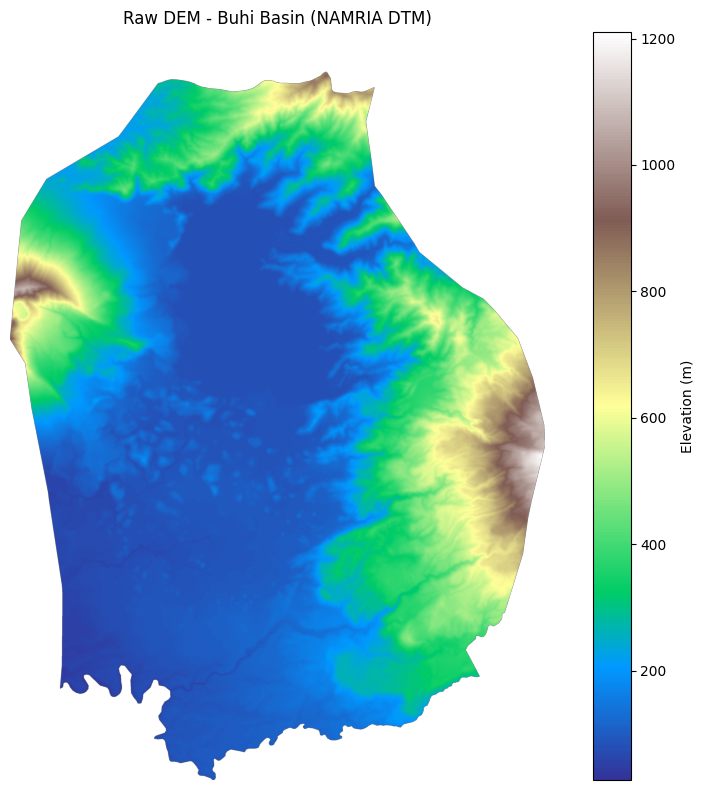

In [15]:
valid_mask = (dem_array != nodata_val) & (dem_array > -100)  # Conservative threshold

print(f"\n✓ Valid basin pixels: {np.sum(valid_mask)} / {dem_array.size}")
print(f"  Basin coverage: {np.sum(valid_mask)/dem_array.size*100:.1f}%")

# Replace NoData with NaN for processing
dem_array = np.where(valid_mask, dem_array, np.nan)

# Show raw DEM with proper masking
plt.figure(figsize=(10, 8))
plt.imshow(dem_array, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('Raw DEM - Buhi Basin (NAMRIA DTM)')
plt.axis('off')
plt.tight_layout()
plt.savefig('dem_raw_masked.png', dpi=150, bbox_inches='tight')
plt.show()

## Downsampling

In [16]:
TARGET_SIZE = 256

# Calculate downsampling factors
downsample_factor_h = TARGET_SIZE / dem_array.shape[0]
downsample_factor_w = TARGET_SIZE / dem_array.shape[1]

print(f"\n⚙️  Downsampling DEM...")
print(f"  Original size: {dem_array.shape}")
print(f"  Target size: {TARGET_SIZE} x {TARGET_SIZE}")

# Downsample the mask first
mask_downsampled = zoom(valid_mask.astype(float), 
                       (downsample_factor_h, downsample_factor_w), 
                       order=1) > 0.5

# For elevation: temporarily fill NaN with mean for interpolation
dem_temp = dem_array.copy()
basin_mean = np.nanmean(dem_array)
dem_temp[np.isnan(dem_temp)] = basin_mean

# Downsample elevation
dem_downsampled = zoom(dem_temp, (downsample_factor_h, downsample_factor_w), order=1)

# Reapply mask to downsampled DEM
dem_downsampled = np.where(mask_downsampled, dem_downsampled, np.nan)

print(f"✓ Downsampled to: {dem_downsampled.shape}")
print(f"  Valid pixels after downsampling: {np.sum(~np.isnan(dem_downsampled))}")


⚙️  Downsampling DEM...
  Original size: (4065, 2907)
  Target size: 256 x 256
✓ Downsampled to: (256, 256)
  Valid pixels after downsampling: 43742


## Normalize


✓ DEM normalized
  Original range: 29.92 to 1198.49 meters
  Normalized range: 0.000 to 1.000
  NaN pixels (outside basin): 21794


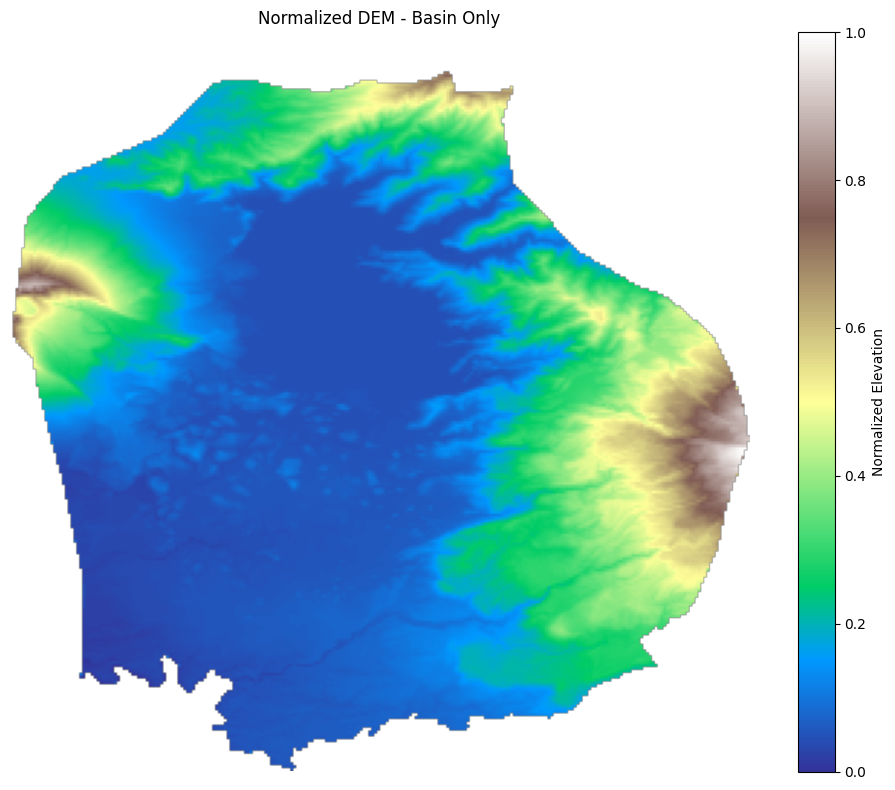

In [17]:
dem_min = np.nanmin(dem_downsampled)
dem_max = np.nanmax(dem_downsampled)

# Normalize only valid pixels
dem_norm = (dem_downsampled - dem_min) / (dem_max - dem_min)

# Keep NaN outside basin
dem_norm = np.where(mask_downsampled, dem_norm, np.nan)

print(f"\n✓ DEM normalized")
print(f"  Original range: {dem_min:.2f} to {dem_max:.2f} meters")
print(f"  Normalized range: {np.nanmin(dem_norm):.3f} to {np.nanmax(dem_norm):.3f}")
print(f"  NaN pixels (outside basin): {np.sum(np.isnan(dem_norm))}")

# Visualize normalized DEM
plt.figure(figsize=(10, 8))
plt.imshow(dem_norm, cmap='terrain')
plt.colorbar(label='Normalized Elevation')
plt.title('Normalized DEM - Basin Only')
plt.axis('off')
plt.tight_layout()
plt.savefig('dem_normalized_masked.png', dpi=150, bbox_inches='tight')
plt.show()

## Export

In [18]:
np.save('dem_norm.npy', dem_norm)
np.save('basin_mask.npy', mask_downsampled)

print("\n✓ Saved: dem_norm.npy")
print("✓ Saved: basin_mask.npy")


✓ Saved: dem_norm.npy
✓ Saved: basin_mask.npy


In [19]:
print("\n" + "="*70)
print("PREPROCESSING COMPLETE - FILES READY FOR STEP 1")
print("="*70)
print("\nInput files:")
print("  1. BUHI_Rainfall-Data.csv     - Raw rainfall time series")
print("  2. BUHI_Riverlevel-Data.csv   - Raw river level time series")
print("  3. BUHI_station_metadata.csv  - Station coordinates")
print("  4. BUHI_DTM.tif               - NAMRIA DEM")
print("  5. BUHI_LAKE.shp              - Buhi Lake boundary")
print("\nGenerated files:")
print("  1. rainfall_norm.csv       - Normalized rainfall time series")
print("  2. riverlevel_norm.csv     - Normalized river level time series")
print("  3. dem_norm.npy            - Normalized DEM array")
print("  4. basin_mask.npy          - Basin mask")
print("\nVisualization files:")
print("  - rainfall_timeseries.png")
print("  - riverlevel_timeseries.png")
print("  - dem_raw_masked.png")
print("  - dem_normalized_masked.png")
print("\n✓ Ready for Spatial Gridding")
print("="*70)


PREPROCESSING COMPLETE - FILES READY FOR STEP 1

Input files:
  1. BUHI_Rainfall-Data.csv     - Raw rainfall time series
  2. BUHI_Riverlevel-Data.csv   - Raw river level time series
  3. BUHI_station_metadata.csv  - Station coordinates
  4. BUHI_DTM.tif               - NAMRIA DEM
  5. BUHI_LAKE.shp              - Buhi Lake boundary

Generated files:
  1. rainfall_norm.csv       - Normalized rainfall time series
  2. riverlevel_norm.csv     - Normalized river level time series
  3. dem_norm.npy            - Normalized DEM array
  4. basin_mask.npy          - Basin mask

Visualization files:
  - rainfall_timeseries.png
  - riverlevel_timeseries.png
  - dem_raw_masked.png
  - dem_normalized_masked.png

✓ Ready for Spatial Gridding


# Spatial Gridding

In [20]:
# ============================================================================
# MEMORY-EFFICIENT SPATIAL GRIDDING (FIXED METADATA STORAGE)
# ============================================================================
import numpy as np
import h5py
from tqdm import tqdm

def create_spatial_grid(station_values, station_coords, dem_shape, basin_mask, method='cubic'):
    """
    Interpolate station point data to spatial grid matching DEM
    MASKED to basin boundary.
    Falls back to 'nearest' if too few stations for cubic/linear.
    Falls back to uniform fill if only 1 station.
    """
    from scipy.interpolate import griddata
    
    n_stations = len(station_coords)
    
    # Create coordinate grid matching DEM extent
    lon_min, lon_max = station_coords[:, 0].min(), station_coords[:, 0].max()
    lat_min, lat_max = station_coords[:, 1].min(), station_coords[:, 1].max()
    
    # Handle single-station case: broadcast value uniformly across basin
    if n_stations == 1:
        grid = np.full(dem_shape, station_values[0], dtype=np.float32)
        grid = np.where(basin_mask, grid, 0.0)
        return grid
    
    # Add buffer (10% on each side)
    lon_buffer = (lon_max - lon_min) * 0.1
    lat_buffer = (lat_max - lat_min) * 0.1
    
    grid_lon = np.linspace(lon_min - lon_buffer, lon_max + lon_buffer, dem_shape[1])
    grid_lat = np.linspace(lat_min - lat_buffer, lat_max + lat_buffer, dem_shape[0])
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # Choose interpolation method based on number of stations
    if n_stations < 4 and method == 'cubic':
        method = 'nearest'
        
    # Interpolate station values to grid
    grid = griddata(
        station_coords, 
        station_values, 
        (grid_lon, grid_lat), 
        method=method,
        fill_value=0.0
    )
    
    # Apply basin mask
    grid = np.where(basin_mask, grid, 0.0)
    
    return grid.astype(np.float32)


def create_spatiotemporal_grids_batched(time_series_df, station_coords, dem_shape, 
                                        basin_mask, output_file, batch_size=500, method='cubic'):
    """
    Create spatial grids in batches and save to HDF5 file to avoid memory issues
    """
    n_timesteps = len(time_series_df)
    n_batches = int(np.ceil(n_timesteps / batch_size))
    n_stations = len(station_coords)
    
    # Auto-select method based on station count
    if n_stations < 4 and method == 'cubic':
        print(f"  ⚠️  Only {n_stations} station(s) — falling back from 'cubic' to 'nearest'")
        method = 'nearest'
    if n_stations == 1:
        print(f"  ℹ️  Single station — using uniform fill across basin mask")
    
    print(f"\nProcessing {n_timesteps} timesteps in {n_batches} batches of {batch_size}")
    print(f"Output: {output_file}")
    
    # Create HDF5 file
    with h5py.File(output_file, 'w') as f:
        # Create main dataset for grids
        grids_dset = f.create_dataset(
            'grids',
            shape=(n_timesteps, dem_shape[0], dem_shape[1]),
            dtype=np.float32,
            chunks=(1, dem_shape[0], dem_shape[1]),
            compression='gzip',
            compression_opts=4
        )
        
        # Save metadata as separate datasets (NOT attributes)
        timestamps_str = time_series_df.index.astype(str).values
        f.create_dataset('timestamps', data=timestamps_str.astype('S'))
        
        stations_str = np.array(time_series_df.columns.tolist(), dtype='S')
        f.create_dataset('stations', data=stations_str)
        
        # Save shape as small attribute
        grids_dset.attrs['height'] = dem_shape[0]
        grids_dset.attrs['width'] = dem_shape[1]
        grids_dset.attrs['n_timesteps'] = n_timesteps
        
        # Process in batches
        for batch_idx in tqdm(range(n_batches), desc="Processing batches"):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, n_timesteps)
            
            # Process batch
            batch_grids = np.zeros((end_idx - start_idx, dem_shape[0], dem_shape[1]), dtype=np.float32)
            
            for i, t in enumerate(range(start_idx, end_idx)):
                station_values = time_series_df.iloc[t].values
                batch_grids[i] = create_spatial_grid(station_values, station_coords, 
                                                     dem_shape, basin_mask, method)
            
            # Write batch to disk
            grids_dset[start_idx:end_idx] = batch_grids
            
            # Clear memory
            del batch_grids
    
    print(f"✓ Saved to {output_file}")
    return output_file


# ============================================================================
# EXECUTE BATCHED GRIDDING
# ============================================================================
print("\n" + "="*70)
print("CREATING MASKED SPATIAL GRIDS (MEMORY-EFFICIENT)")
print("="*70)

# Load basin mask
basin_mask = np.load('basin_mask.npy')

# Process rainfall
print("\n[1/2] Processing Rainfall Data...")
rainfall_file = create_spatiotemporal_grids_batched(
    rainfall_norm, 
    rainfall_coords, 
    dem_norm.shape, 
    basin_mask,
    output_file='rainfall_grids.h5',
    batch_size=500,
    method='cubic'
)

# Process river level
print("\n[2/2] Processing River Level Data...")
riverlevel_file = create_spatiotemporal_grids_batched(
    riverlevel_norm, 
    riverlevel_coords, 
    dem_norm.shape, 
    basin_mask,
    output_file='riverlevel_grids.h5',
    batch_size=500,
    method='cubic'
)

print("\n" + "="*70)
print("✅ SPATIAL GRIDDING COMPLETE")
print("="*70)
print(f"✓ Rainfall: {rainfall_file}")
print(f"✓ River Level: {riverlevel_file}")


CREATING MASKED SPATIAL GRIDS (MEMORY-EFFICIENT)

[1/2] Processing Rainfall Data...
  ⚠️  Only 1 station(s) — falling back from 'cubic' to 'nearest'
  ℹ️  Single station — using uniform fill across basin mask

Processing 9008 timesteps in 19 batches of 500
Output: rainfall_grids.h5


Processing batches: 100%|██████████| 19/19 [00:12<00:00,  1.51it/s]


✓ Saved to rainfall_grids.h5

[2/2] Processing River Level Data...
  ⚠️  Only 1 station(s) — falling back from 'cubic' to 'nearest'
  ℹ️  Single station — using uniform fill across basin mask

Processing 9008 timesteps in 19 batches of 500
Output: riverlevel_grids.h5


Processing batches: 100%|██████████| 19/19 [00:13<00:00,  1.44it/s]


✓ Saved to riverlevel_grids.h5

✅ SPATIAL GRIDDING COMPLETE
✓ Rainfall: rainfall_grids.h5
✓ River Level: riverlevel_grids.h5



VISUALIZING SAMPLE GRIDS
Rainfall grid shape: (9008, 256, 256)
Sample timestamps: ['2024-10-19 01:00:00', '2025-04-24 17:00:00', '2025-10-29 08:00:00']
River level grid shape: (9008, 256, 256)
Sample timestamps: ['2024-10-19 01:00:00', '2025-04-24 17:00:00', '2025-10-29 08:00:00']


C:\Users\Selwyn Lao\AppData\Local\Temp\ipykernel_29492\778806595.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


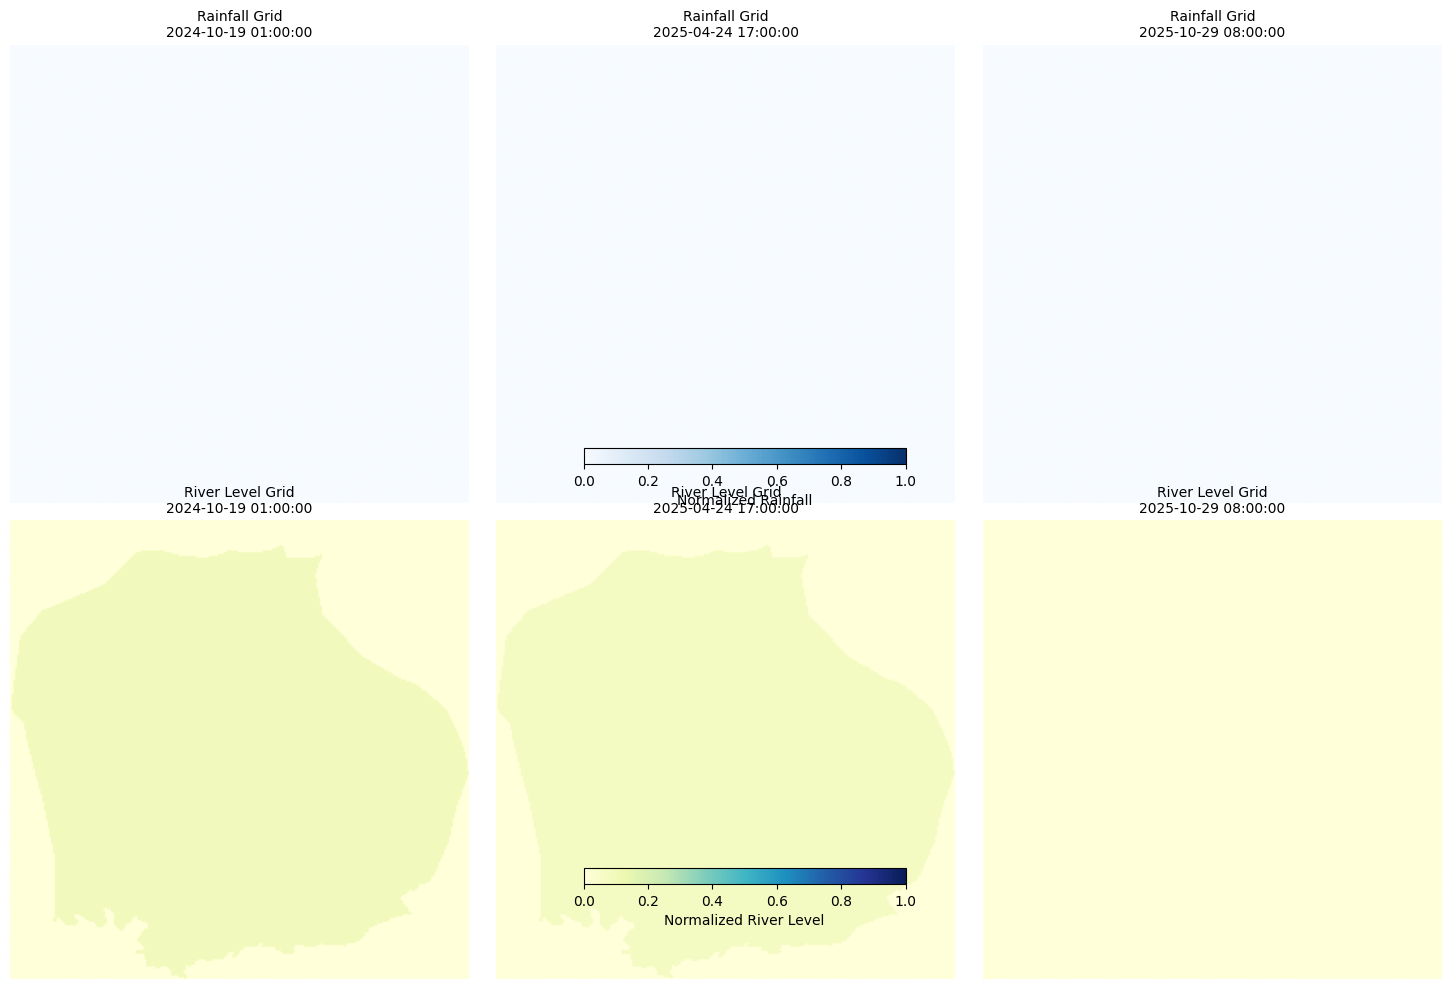


✓ Saved visualization: spatial_grids_sample_masked.png


In [21]:
# ============================================================================
# VISUALIZE SAMPLES FROM HDF5 FILES
# ============================================================================
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("VISUALIZING SAMPLE GRIDS")
print("="*70)

# Load samples from HDF5
with h5py.File('rainfall_grids.h5', 'r') as f:
    n_total = f['grids'].shape[0]
    sample_indices = [0, n_total//2, n_total-1]
    
    rainfall_grids_sample = f['grids'][sample_indices]
    rain_timestamps = f['timestamps'][sample_indices]
    
    print(f"Rainfall grid shape: {f['grids'].shape}")
    print(f"Sample timestamps: {[ts.decode() for ts in rain_timestamps]}")

with h5py.File('riverlevel_grids.h5', 'r') as f:
    n_total = f['grids'].shape[0]
    sample_indices = [0, n_total//2, n_total-1]
    
    riverlevel_grids_sample = f['grids'][sample_indices]
    river_timestamps = f['timestamps'][sample_indices]
    
    print(f"River level grid shape: {f['grids'].shape}")
    print(f"Sample timestamps: {[ts.decode() for ts in river_timestamps]}")

# Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx in range(3):
    # Rainfall
    im1 = axes[0, idx].imshow(rainfall_grids_sample[idx], cmap='Blues', vmin=0, vmax=1)
    axes[0, idx].set_title(f'Rainfall Grid\n{rain_timestamps[idx].decode()}', fontsize=10)
    axes[0, idx].axis('off')
    
    # River level
    im2 = axes[1, idx].imshow(riverlevel_grids_sample[idx], cmap='YlGnBu', vmin=0, vmax=1)
    axes[1, idx].set_title(f'River Level Grid\n{river_timestamps[idx].decode()}', fontsize=10)
    axes[1, idx].axis('off')

# Add colorbars
fig.colorbar(im1, ax=axes[0, :], orientation='horizontal', pad=0.05, fraction=0.046, label='Normalized Rainfall')
fig.colorbar(im2, ax=axes[1, :], orientation='horizontal', pad=0.05, fraction=0.046, label='Normalized River Level')

plt.tight_layout()
plt.savefig('spatial_grids_sample_masked.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization: spatial_grids_sample_masked.png")

In [22]:
# ============================================================================
# DATA INTEGRITY CHECK
# ============================================================================
print("\n" + "="*70)
print("DATA INTEGRITY CHECK")
print("="*70)

with h5py.File('rainfall_grids.h5', 'r') as f:
    print("\nRainfall Data:")
    print(f"  Grid shape: {f['grids'].shape}")
    print(f"  Data type: {f['grids'].dtype}")
    print(f"  Number of timestamps: {len(f['timestamps'])}")
    print(f"  Number of stations: {len(f['stations'])}")
    
    # Check for NaN/Inf
    sample = f['grids'][0]
    print(f"  Contains NaN: {np.any(np.isnan(sample))}")
    print(f"  Contains Inf: {np.any(np.isinf(sample))}")
    print(f"  Value range: [{np.min(sample):.4f}, {np.max(sample):.4f}]")
    print(f"  Non-zero pixels: {np.sum(sample != 0)}/{sample.size}")

with h5py.File('riverlevel_grids.h5', 'r') as f:
    print("\nRiver Level Data:")
    print(f"  Grid shape: {f['grids'].shape}")
    print(f"  Data type: {f['grids'].dtype}")
    print(f"  Number of timestamps: {len(f['timestamps'])}")
    print(f"  Number of stations: {len(f['stations'])}")
    
    sample = f['grids'][0]
    print(f"  Contains NaN: {np.any(np.isnan(sample))}")
    print(f"  Contains Inf: {np.any(np.isinf(sample))}")
    print(f"  Value range: [{np.min(sample):.4f}, {np.max(sample):.4f}]")
    print(f"  Non-zero pixels: {np.sum(sample != 0)}/{sample.size}")

# Check file sizes
import os
print("\n" + "="*70)
print("FILE SIZES")
print("="*70)
print(f"rainfall_grids.h5: {os.path.getsize('rainfall_grids.h5') / (1024**2):.1f} MB")
print(f"riverlevel_grids.h5: {os.path.getsize('riverlevel_grids.h5') / (1024**2):.1f} MB")


DATA INTEGRITY CHECK

Rainfall Data:
  Grid shape: (9008, 256, 256)
  Data type: float32
  Number of timestamps: 9008
  Number of stations: 1
  Contains NaN: False
  Contains Inf: False
  Value range: [0.0000, 0.0000]
  Non-zero pixels: 0/65536

River Level Data:
  Grid shape: (9008, 256, 256)
  Data type: float32
  Number of timestamps: 9008
  Number of stations: 1
  Contains NaN: False
  Contains Inf: False
  Value range: [0.0000, 0.0921]
  Non-zero pixels: 43742/65536

FILE SIZES
rainfall_grids.h5: 4.9 MB
riverlevel_grids.h5: 13.7 MB



VERIFYING STATION LOCATIONS ON DEM


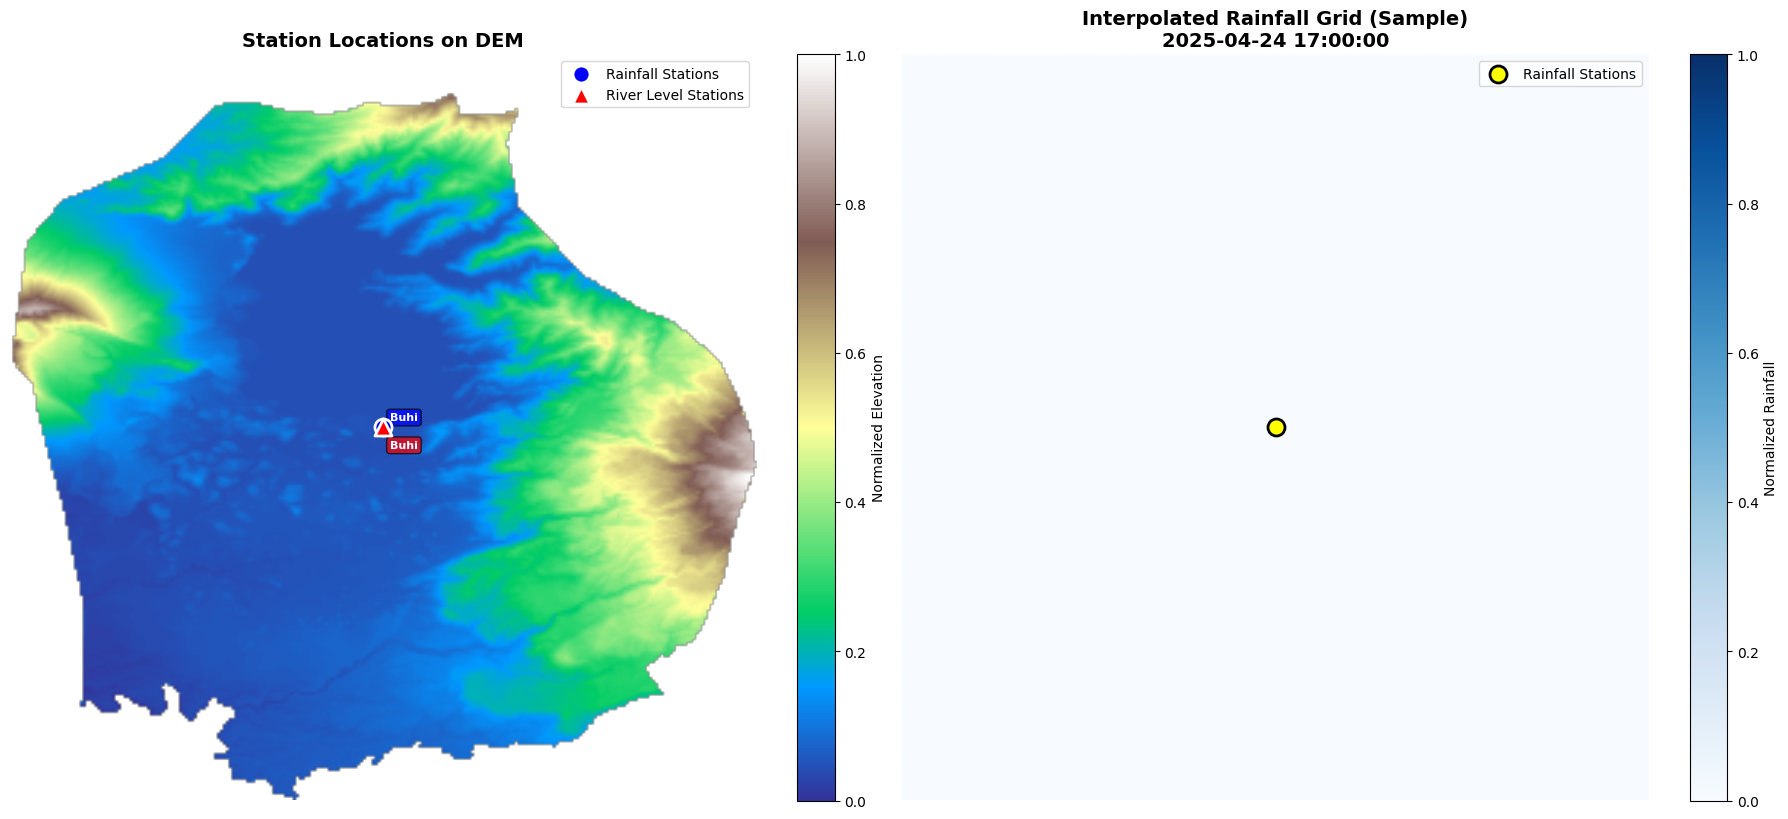


✓ Saved: station_verification.png

STATION PIXEL COORDINATES

Rainfall Stations:
  Buhi        : ( 127.5,  127.5) | Geo: (123.5090, 13.4337)

River Level Stations:
  Buhi        : ( 127.5,  127.5) | Geo: (123.5090, 13.4337)

BOUNDS CHECK
Rainfall stations in bounds: True ✓
River level stations in bounds: True ✓



In [23]:
# ============================================================================
# STATION LOCATION VERIFICATION
# ============================================================================
print("\n" + "="*70)
print("VERIFYING STATION LOCATIONS ON DEM")
print("="*70)

# Get DEM extent for proper coordinate transformation
dem_height, dem_width = dem_norm.shape

# Get coordinate ranges from stations
all_coords = np.vstack([rainfall_coords, riverlevel_coords])
lon_min, lon_max = all_coords[:, 0].min(), all_coords[:, 0].max()
lat_min, lat_max = all_coords[:, 1].min(), all_coords[:, 1].max()

# Add buffer (same as in your gridding function)
lon_range = lon_max - lon_min if lon_max != lon_min else 0.01  # avoid zero range
lat_range = lat_max - lat_min if lat_max != lat_min else 0.01
lon_buffer = lon_range * 0.1
lat_buffer = lat_range * 0.1

# Function to convert geographic coords to pixel coords
def geo_to_pixel(coords, lon_min, lon_max, lat_min, lat_max, width, height):
    """Convert lon/lat to pixel coordinates"""
    lon_span = (lon_max + lon_buffer) - (lon_min - lon_buffer)
    lat_span = (lat_max + lat_buffer) - (lat_min - lat_buffer)
    
    if lon_span == 0:
        x = np.full(len(coords), width / 2.0)
    else:
        x = ((coords[:, 0] - (lon_min - lon_buffer)) / lon_span * (width - 1))
    
    if lat_span == 0:
        y = np.full(len(coords), height / 2.0)
    else:
        y = ((coords[:, 1] - (lat_min - lat_buffer)) / lat_span * (height - 1))
    
    # Flip y-axis (images have origin at top-left)
    y = height - 1 - y
    return x, y

# Convert station coords to pixel coords
rain_x, rain_y = geo_to_pixel(rainfall_coords, lon_min, lon_max, 
                               lat_min, lat_max, dem_width, dem_height)
river_x, river_y = geo_to_pixel(riverlevel_coords, lon_min, lon_max, 
                                lat_min, lat_max, dem_width, dem_height)

# Create figure with station overlay
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: DEM with stations
ax = axes[0]
im = ax.imshow(dem_norm, cmap='terrain', interpolation='bilinear')
ax.scatter(rain_x, rain_y, c='blue', s=150, marker='o', 
          label='Rainfall Stations', edgecolors='white', linewidths=2, zorder=5)
ax.scatter(river_x, river_y, c='red', s=150, marker='^', 
          label='River Level Stations', edgecolors='white', linewidths=2, zorder=5)

# Add station labels
for i, name in enumerate(rainfall_norm.columns):
    ax.annotate(name, (rain_x[i], rain_y[i]), 
               xytext=(5, 5), textcoords='offset points',
               fontsize=8, color='white', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='blue', alpha=0.7))

for i, name in enumerate(riverlevel_norm.columns):
    ax.annotate(name, (river_x[i], river_y[i]), 
               xytext=(5, -15), textcoords='offset points',
               fontsize=8, color='white', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7))

ax.set_title('Station Locations on DEM', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.axis('off')
plt.colorbar(im, ax=ax, label='Normalized Elevation', fraction=0.046)

# Right plot: Sample interpolated grid with stations (load from HDF5)
ax = axes[1]
with h5py.File('rainfall_grids.h5', 'r') as f:
    n_total = f['grids'].shape[0]
    sample_grid = f['grids'][n_total // 2]  # Middle timestep

im = ax.imshow(sample_grid, cmap='Blues', vmin=0, vmax=sample_grid.max() or 1, interpolation='bilinear')
ax.scatter(rain_x, rain_y, c='yellow', s=150, marker='o', 
          edgecolors='black', linewidths=2, zorder=5, label='Rainfall Stations')
ax.set_title(f'Interpolated Rainfall Grid (Sample)\n{rainfall_norm.index[n_total // 2]}', 
            fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.axis('off')
plt.colorbar(im, ax=ax, label='Normalized Rainfall', fraction=0.046)

plt.tight_layout()
plt.savefig('station_verification.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n✓ Saved: station_verification.png")

# Print station pixel coordinates
print("\n" + "="*70)
print("STATION PIXEL COORDINATES")
print("="*70)
print("\nRainfall Stations:")
for i, name in enumerate(rainfall_norm.columns):
    print(f"  {name:12s}: ({rain_x[i]:6.1f}, {rain_y[i]:6.1f}) | "
          f"Geo: ({rainfall_coords[i,0]:.4f}, {rainfall_coords[i,1]:.4f})")

print("\nRiver Level Stations:")
for i, name in enumerate(riverlevel_norm.columns):
    print(f"  {name:12s}: ({river_x[i]:6.1f}, {river_y[i]:6.1f}) | "
          f"Geo: ({riverlevel_coords[i,0]:.4f}, {riverlevel_coords[i,1]:.4f})")

# Sanity check: are stations within grid bounds?
print("\n" + "="*70)
print("BOUNDS CHECK")
print("="*70)
rain_in_bounds = np.all((rain_x >= 0) & (rain_x < dem_width) & 
                        (rain_y >= 0) & (rain_y < dem_height))
river_in_bounds = np.all((river_x >= 0) & (river_x < dem_width) & 
                         (river_y >= 0) & (river_y < dem_height))

print(f"Rainfall stations in bounds: {rain_in_bounds} ✓" if rain_in_bounds 
      else f"⚠️  WARNING: Some rainfall stations outside grid!")
print(f"River level stations in bounds: {river_in_bounds} ✓" if river_in_bounds 
      else f"⚠️  WARNING: Some river level stations outside grid!")

print("\n" + "="*70)

# Sequence Generation

In [24]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

print("="*50)
print("LOADING DATA")
print("="*50)

# Load grids from HDF5 files (created by spatial gridding step)
with h5py.File('rainfall_grids.h5', 'r') as f:
    rainfall_grids = f['grids'][:]
with h5py.File('riverlevel_grids.h5', 'r') as f:
    riverlevel_grids = f['grids'][:]
dem_norm = np.load('dem_norm.npy')

print(f"✓ Loaded data shapes:")
print(f"  Rainfall grids: {rainfall_grids.shape}")
print(f"  River level grids: {riverlevel_grids.shape}")
print(f"  DEM: {dem_norm.shape}")

LOADING DATA
✓ Loaded data shapes:
  Rainfall grids: (9008, 256, 256)
  River level grids: (9008, 256, 256)
  DEM: (256, 256)


In [25]:
INPUT_TIMESTEPS = 12  # Use past 12 hours to predict
OUTPUT_TIMESTEPS = 6  # Predict next 6 hours
STRIDE = 6  # INCREASED FROM 1 - Creates fewer sequences to save memory

print(f"\nSequence parameters:")
print(f"  Input timesteps: {INPUT_TIMESTEPS} hours")
print(f"  Output timesteps: {OUTPUT_TIMESTEPS} hours")
print(f"  Stride: {STRIDE}")
print(f"  ⚠️  STRIDE={STRIDE} means we skip some data to reduce memory usage")


Sequence parameters:
  Input timesteps: 12 hours
  Output timesteps: 6 hours
  Stride: 6
  ⚠️  STRIDE=6 means we skip some data to reduce memory usage


In [26]:
def create_sequences_optimized(rainfall_grids, riverlevel_grids, dem_norm, 
                               input_steps, output_steps, stride=1):
    """
    Memory-optimized sequence creation using pre-allocated numpy arrays
    
    Args:
        rainfall_grids: array (T, H, W) - rainfall spatial grids
        riverlevel_grids: array (T, H, W) - river level spatial grids
        dem_norm: array (H, W) - normalized DEM (static)
        input_steps: int - number of past timesteps as input
        output_steps: int - number of future timesteps to predict
        stride: int - sliding window stride
    
    Returns:
        X: array (N, input_steps, H, W, C) - input sequences
        y: array (N, output_steps, H, W, 1) - output sequences
    """
    T, H, W = rainfall_grids.shape
    
    # Calculate number of sequences
    n_sequences = (T - input_steps - output_steps) // stride + 1
    
    print(f"\n" + "="*50)
    print("MEMORY ESTIMATION")
    print("="*50)
    
    # Estimate memory requirements
    X_size_gb = (n_sequences * input_steps * H * W * 3 * 4) / (1024**3)  # 4 bytes per float32
    y_size_gb = (n_sequences * output_steps * H * W * 1 * 4) / (1024**3)
    total_gb = X_size_gb + y_size_gb
    
    print(f"  Number of sequences: {n_sequences}")
    print(f"  Estimated X size: {X_size_gb:.2f} GB")
    print(f"  Estimated y size: {y_size_gb:.2f} GB")
    print(f"  Total memory needed: {total_gb:.2f} GB")
    
    if total_gb > 50:
        print(f"\n  ⚠️  WARNING: This requires {total_gb:.0f} GB of memory!")
        print(f"  Consider increasing STRIDE to reduce sequences")
        user_input = input("  Continue anyway? (yes/no): ").strip().lower()
        if user_input != 'yes':
            print("  Aborting. Please increase STRIDE value.")
            return None, None
    
    print(f"\n" + "="*50)
    print("CREATING SEQUENCES")
    print("="*50)
    print(f"  Total timesteps: {T}")
    print(f"  Input timesteps: {input_steps}")
    print(f"  Output timesteps: {output_steps}")
    print(f"  Stride: {stride}")
    print()
    
    # PRE-ALLOCATE arrays (much more memory efficient than lists!)
    X = np.zeros((n_sequences, input_steps, H, W, 3), dtype=np.float32)
    y = np.zeros((n_sequences, output_steps, H, W, 1), dtype=np.float32)
    
    print("  Arrays allocated. Creating sequences...")
    
    seq_idx = 0
    for i in range(0, T - input_steps - output_steps + 1, stride):
        # Input sequence
        for t in range(input_steps):
            X[seq_idx, t, :, :, 0] = rainfall_grids[i + t]      # Rainfall
            X[seq_idx, t, :, :, 1] = riverlevel_grids[i + t]    # River level
            X[seq_idx, t, :, :, 2] = dem_norm                   # DEM (static)
        
        # Output sequence
        for t in range(output_steps):
            y[seq_idx, t, :, :, 0] = riverlevel_grids[i + input_steps + t]
        
        seq_idx += 1
        
        if seq_idx % 1000 == 0:
            print(f"  Created {seq_idx}/{n_sequences} sequences...")
    
    print(f"\n✓ Sequence creation complete!")
    print(f"  X shape: {X.shape} (samples, input_steps, H, W, channels)")
    print(f"  y shape: {y.shape} (samples, output_steps, H, W, 1)")
    print(f"  X dtype: {X.dtype}")
    print(f"  y dtype: {y.dtype}")
    
    # Actual memory usage
    X_memory = X.nbytes / (1024**3)  # GB
    y_memory = y.nbytes / (1024**3)  # GB
    print(f"\nActual memory usage:")
    print(f"  X: {X_memory:.2f} GB")
    print(f"  y: {y_memory:.2f} GB")
    print(f"  Total: {X_memory + y_memory:.2f} GB")
    
    return X, y

In [53]:
# Fill NaN in DEM (outside-basin pixels) with 0 so they don't poison training
dem_norm = np.nan_to_num(dem_norm, nan=0.0)
print(f"DEM NaN after cleanup: {np.isnan(dem_norm).sum()}")

X, y = create_sequences_optimized(
    rainfall_grids, 
    riverlevel_grids, 
    dem_norm,
    input_steps=INPUT_TIMESTEPS,
    output_steps=OUTPUT_TIMESTEPS,
    stride=STRIDE
)

DEM NaN after cleanup: 0

MEMORY ESTIMATION
  Number of sequences: 1499
  Estimated X size: 13.17 GB
  Estimated y size: 2.20 GB
  Total memory needed: 15.37 GB

CREATING SEQUENCES
  Total timesteps: 9008
  Input timesteps: 12
  Output timesteps: 6
  Stride: 6

  Arrays allocated. Creating sequences...
  Created 1000/1499 sequences...

✓ Sequence creation complete!
  X shape: (1499, 12, 256, 256, 3) (samples, input_steps, H, W, channels)
  y shape: (1499, 6, 256, 256, 1) (samples, output_steps, H, W, 1)
  X dtype: float32
  y dtype: float32

Actual memory usage:
  X: 13.17 GB
  y: 2.20 GB
  Total: 15.37 GB


In [54]:
if X is None or y is None:
    print("\n❌ Sequence creation aborted. Please adjust STRIDE and try again.")
    exit()

In [55]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

n_samples = len(X)
train_size = int(n_samples * train_ratio)
val_size = int(n_samples * val_ratio)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("\n" + "="*50)
print("DATASET SPLITS")
print("="*50)
print(f"Training set:   {X_train.shape[0]:5d} samples ({train_ratio*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]:5d} samples ({val_ratio*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]:5d} samples ({test_ratio*100:.0f}%)")
print(f"{'─'*50}")
print(f"Total:          {n_samples:5d} samples (100%)")


DATASET SPLITS
Training set:    1049 samples (70%)
Validation set:   224 samples (15%)
Test set:         226 samples (15%)
──────────────────────────────────────────────────
Total:           1499 samples (100%)


River level scaler range: 0.00m – 3.15m
Alert   (1.6m)    → normalized: 0.5079
Alarm   (2.4m)    → normalized: 0.7619
Critical(4.0m) → normalized: 1.0000

✓ Custom flood-level colormap created
  Blue → Yellow (Alert 1.6m) → Orange (Alarm 2.4m) → Red (Critical 4.0m)

VISUALIZING SAMPLE SEQUENCES


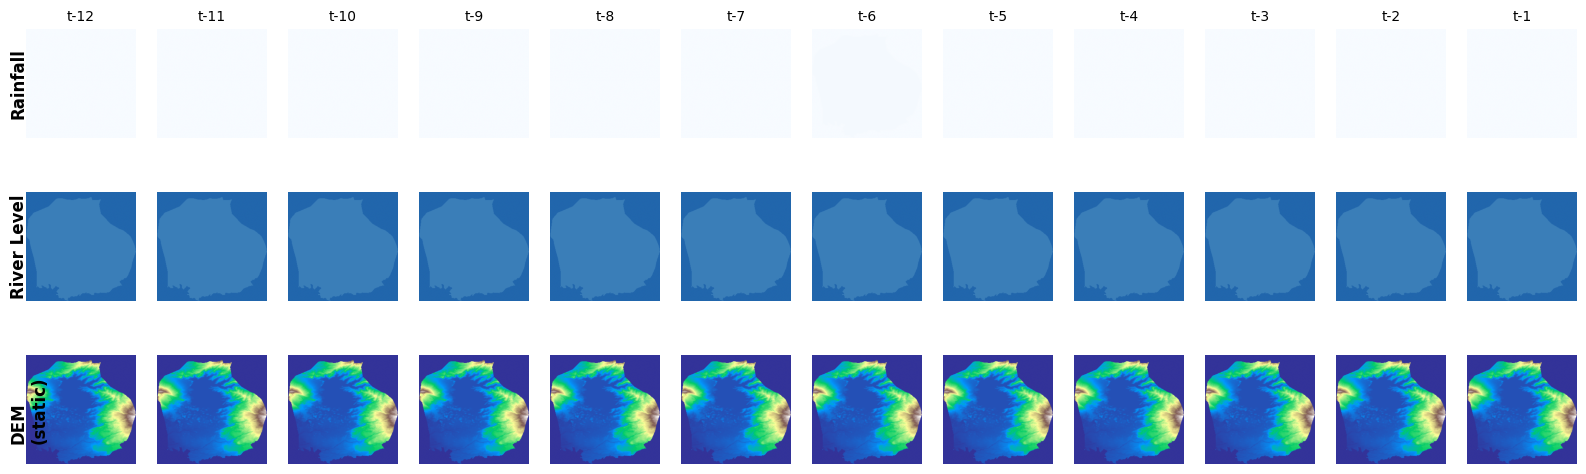

In [56]:
import matplotlib.colors as mcolors

# ============================================================================
# FLOOD ALERT THRESHOLDS (in meters) → normalized using river_scaler
# ============================================================================
ALERT_M = 1.6    # Alert level
ALARM_M = 2.4    # Alarm level  
CRITICAL_M = 4.0 # Critical level

# Convert thresholds to normalized [0,1] using the river_scaler
river_min = river_scaler.data_min_[0]
river_max = river_scaler.data_max_[0]
river_range = river_max - river_min

alert_norm = (ALERT_M - river_min) / river_range if river_range > 0 else 0
alarm_norm = (ALARM_M - river_min) / river_range if river_range > 0 else 0
critical_norm = (CRITICAL_M - river_min) / river_range if river_range > 0 else 0

# Clamp to [0, 1]
alert_norm = np.clip(alert_norm, 0, 1)
alarm_norm = np.clip(alarm_norm, 0, 1)
critical_norm = np.clip(critical_norm, 0, 1)

print(f"River level scaler range: {river_min:.2f}m – {river_max:.2f}m")
print(f"Alert   ({ALERT_M}m)    → normalized: {alert_norm:.4f}")
print(f"Alarm   ({ALARM_M}m)    → normalized: {alarm_norm:.4f}")
print(f"Critical({CRITICAL_M}m) → normalized: {critical_norm:.4f}")

# Build custom colormap: Normal → Alert(yellow) → Alarm(orange) → Critical(red)
flood_cmap_colors = [
    (0.0,          '#2166ac'),   # Deep blue  - low/normal
    (alert_norm,   '#67a9cf'),   # Light blue - approaching alert
    (alert_norm,   '#fdd835'),   # Yellow     - alert threshold
    (alarm_norm,   '#fb8c00'),   # Orange     - alarm threshold
    (critical_norm,'#d32f2f'),   # Red        - critical threshold
    (1.0,          '#7b0000'),   # Dark red   - above critical
]

# If thresholds exceed scaler range, truncate the colormap stops
flood_cmap_colors = [(pos, col) for pos, col in flood_cmap_colors if pos <= 1.0]
# Ensure we end at 1.0
if flood_cmap_colors[-1][0] < 1.0:
    flood_cmap_colors.append((1.0, flood_cmap_colors[-1][1]))

flood_cmap = mcolors.LinearSegmentedColormap.from_list(
    'flood_levels', flood_cmap_colors
)

print("\n✓ Custom flood-level colormap created")
print("  Blue → Yellow (Alert 1.6m) → Orange (Alarm 2.4m) → Red (Critical 4.0m)")

# ============================================================================
# VISUALIZE INPUT SEQUENCES WITH FLOOD COLORMAP
# ============================================================================
print("\n" + "="*50)
print("VISUALIZING SAMPLE SEQUENCES")
print("="*50)

fig, axes = plt.subplots(3, INPUT_TIMESTEPS, figsize=(20, 6))

sample_idx = min(100, len(X_train) - 1)

for t in range(INPUT_TIMESTEPS):
    # Rainfall
    axes[0, t].imshow(X_train[sample_idx, t, :, :, 0], cmap='Blues', vmin=0, vmax=1)
    axes[0, t].set_title(f't-{INPUT_TIMESTEPS-t}', fontsize=10)
    axes[0, t].axis('off')
    if t == 0:
        axes[0, t].text(-0.15, 0.5, 'Rainfall', transform=axes[0, t].transAxes,
                       fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # River Level — with flood alert colormap
    im_rl = axes[1, t].imshow(X_train[sample_idx, t, :, :, 1], cmap=flood_cmap, vmin=0, vmax=1)
    axes[1, t].axis('off')
    if t == 0:
        axes[1, t].text(-0.15, 0.5, 'River Level', transform=axes[1, t].transAxes,
                       fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # DEM
    axes[2, t].imshow(X_train[sample_idx, t, :, :, 2], cmap='terrain', vmin=0, vmax=1)
    axes[2, t].axis('off')
    if t == 0:
        axes[2, t].text(-0.15, 0.5, 'DEM\n(static)', transform=axes[2, t].transAxes,
                       fontsize=12, fontweight='bold', va='center', rotation=90)

In [57]:
plt.suptitle(f'Sample Input Sequence (Past {INPUT_TIMESTEPS} hours)', 
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.92, 0.95])

# Add flood-level colorbar for river level row
cbar_ax = fig.add_axes([0.93, 0.38, 0.015, 0.25])
cbar = fig.colorbar(im_rl, cax=cbar_ax)
cbar.set_label('River Level', fontsize=9)
# Mark alert thresholds on colorbar
for level, label, color in [(alert_norm, f'Alert {ALERT_M}m', '#fdd835'),
                             (alarm_norm, f'Alarm {ALARM_M}m', '#fb8c00'),
                             (critical_norm, f'Critical {CRITICAL_M}m', '#d32f2f')]:
    if 0 < level <= 1:
        cbar.ax.axhline(y=level, color='black', linewidth=1.5, linestyle='--')
        cbar.ax.text(1.3, level, label, transform=cbar.ax.get_yaxis_transform(),
                    fontsize=7, va='center', fontweight='bold', color=color)

plt.savefig('sample_input_sequence.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: sample_input_sequence.png")

<Figure size 640x480 with 0 Axes>

✓ Saved: sample_input_sequence.png


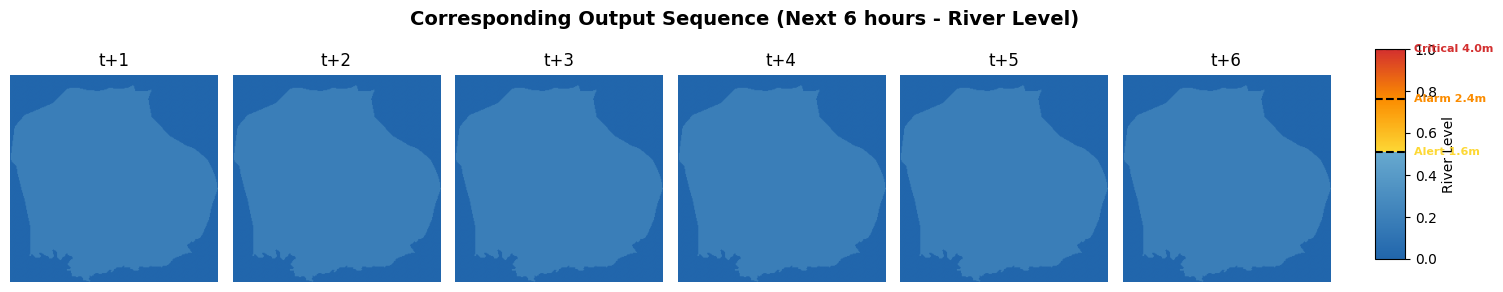

✓ Saved: sample_output_sequence.png


In [58]:
fig, axes = plt.subplots(1, OUTPUT_TIMESTEPS, figsize=(15, 3))

for t in range(OUTPUT_TIMESTEPS):
    im_out = axes[t].imshow(y_train[sample_idx, t, :, :, 0], cmap=flood_cmap, vmin=0, vmax=1)
    axes[t].set_title(f't+{t+1}', fontsize=12)
    axes[t].axis('off')

plt.suptitle(f'Corresponding Output Sequence (Next {OUTPUT_TIMESTEPS} hours - River Level)', 
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.90, 0.95])

# Add flood-level colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im_out, cax=cbar_ax)
cbar.set_label('River Level', fontsize=10)
for level, label, color in [(alert_norm, f'Alert {ALERT_M}m', '#fdd835'),
                             (alarm_norm, f'Alarm {ALARM_M}m', '#fb8c00'),
                             (critical_norm, f'Critical {CRITICAL_M}m', '#d32f2f')]:
    if 0 < level <= 1:
        cbar.ax.axhline(y=level, color='black', linewidth=1.5, linestyle='--')
        cbar.ax.text(1.3, level, label, transform=cbar.ax.get_yaxis_transform(),
                    fontsize=8, va='center', fontweight='bold', color=color)

plt.savefig('sample_output_sequence.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: sample_output_sequence.png")

In [59]:
print("\n" + "="*50)
print("DATA STATISTICS")
print("="*50)

print("\nInput data (X) statistics:")
print(f"  Channel 0 (Rainfall):    min={X[:,:,:,:,0].min():.4f}, max={X[:,:,:,:,0].max():.4f}, mean={X[:,:,:,:,0].mean():.4f}")
print(f"  Channel 1 (River Level): min={X[:,:,:,:,1].min():.4f}, max={X[:,:,:,:,1].max():.4f}, mean={X[:,:,:,:,1].mean():.4f}")
print(f"  Channel 2 (DEM):         min={X[:,:,:,:,2].min():.4f}, max={X[:,:,:,:,2].max():.4f}, mean={X[:,:,:,:,2].mean():.4f}")

print("\nOutput data (y) statistics:")
print(f"  River Level (target):    min={y.min():.4f}, max={y.max():.4f}, mean={y.mean():.4f}")


DATA STATISTICS

Input data (X) statistics:
  Channel 0 (Rainfall):    min=0.0000, max=1.0000, mean=0.0043
  Channel 1 (River Level): min=0.0000, max=1.0000, mean=0.0958
  Channel 2 (DEM):         min=0.0000, max=1.0000, mean=0.1281

Output data (y) statistics:
  River Level (target):    min=0.0000, max=1.0000, mean=0.0957


In [ ]:
import gc, os

print("\n" + "="*50)
print("SAVING DATASETS")
print("="*50)

# Release any lingering memmap file handles from earlier diagnostic cells
gc.collect()

def save_large_npy(filename, data):
    """Save large numpy arrays safely on Windows."""
    abs_path = os.path.abspath(filename)
    # Remove old file if it exists (may be locked by old memmap)
    if os.path.exists(abs_path):
        try:
            os.remove(abs_path)
        except PermissionError:
            # File locked — save with alternate name
            abs_path = abs_path.replace('.npy', '_new.npy')
            print(f"  ⚠️  Old file locked, saving as {os.path.basename(abs_path)}")
    
    # Write header + data manually in chunks to avoid >4 GB single-write issue
    with open(abs_path, 'wb') as f:
        # Write npy header
        np.lib.format.write_array_header_2_0(f, 
            {'descr': np.lib.format.dtype_to_descr(data.dtype),
             'fortran_order': False,
             'shape': data.shape})
        # Write data in chunks (100 samples at a time)
        chunk = 100
        for start in range(0, len(data), chunk):
            end = min(start + chunk, len(data))
            f.write(data[start:end].tobytes())

save_large_npy('X_train.npy', X_train)
print("✓ Saved: X_train.npy")
save_large_npy('y_train.npy', y_train)
print("✓ Saved: y_train.npy")
save_large_npy('X_val.npy', X_val)
print("✓ Saved: X_val.npy")
save_large_npy('y_val.npy', y_val)
print("✓ Saved: y_val.npy")
save_large_npy('X_test.npy', X_test)
print("✓ Saved: X_test.npy")
save_large_npy('y_test.npy', y_test)
print("✓ Saved: y_test.npy")

# Summary
print("\n" + "="*50)
print("SEQUENCE GENERATION COMPLETE")
print("="*50)
print("\n✓ All sequences created and saved successfully!")
print("✓ Training, validation, and test sets ready")
print("✓ Visualizations saved")
print(f"\n📊 Final dataset sizes:")
print(f"  Training: {len(X_train)} sequences")
print(f"  Validation: {len(X_val)} sequences")
print(f"  Test: {len(X_test)} sequences")
print("="*50)


SAVING DATASETS


OSError: [Errno 22] Invalid argument: 'X_train.npy'

# ConvLSTM Model

In [36]:
!pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Load datasets to get dimensions
print("="*50)
print("LOADING DATA TO GET DIMENSIONS")
print("="*50)

X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

print("Dataset shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

Defaulting to user installation because normal site-packages is not writeable
LOADING DATA TO GET DIMENSIONS


Dataset shapes:
  X_train: (1049, 12, 256, 256, 3)
  y_train: (1049, 6, 256, 256, 1)
  X_val: (224, 12, 256, 256, 3)
  y_val: (224, 6, 256, 256, 1)
  X_test: (226, 12, 256, 256, 3)
  y_test: (226, 6, 256, 256, 1)


In [37]:
INPUT_TIMESTEPS = X_train.shape[1]
OUTPUT_TIMESTEPS = y_train.shape[1]
HEIGHT = X_train.shape[2]
WIDTH = X_train.shape[3]
INPUT_CHANNELS = X_train.shape[4]

print(f"\nModel configuration:")
print(f"  Input timesteps: {INPUT_TIMESTEPS}")
print(f"  Output timesteps: {OUTPUT_TIMESTEPS}")
print(f"  Spatial dimensions: {HEIGHT} x {WIDTH}")
print(f"  Input channels: {INPUT_CHANNELS}")


Model configuration:
  Input timesteps: 12
  Output timesteps: 6
  Spatial dimensions: 256 x 256
  Input channels: 3


In [38]:
def build_convlstm_model(input_shape, output_timesteps):
    """
    Build ConvLSTM model for spatiotemporal river level prediction
    
    Architecture:
    - ConvLSTM2D layers to capture spatiotemporal patterns
    - Batch Normalization for training stability
    - TimeDistributed Conv2D for multi-step prediction
    
    Args:
        input_shape: (timesteps, height, width, channels)
        output_timesteps: number of future timesteps to predict
    
    Returns:
        model: Keras model
    """
    
    print("\n" + "="*50)
    print("BUILDING MODEL ARCHITECTURE")
    print("="*50)
    
    inputs = layers.Input(shape=input_shape)
    
    # Encoder: ConvLSTM layers to capture spatiotemporal patterns
    print("Adding ConvLSTM2D layer 1 (64 filters)...")
    x = layers.ConvLSTM2D(
        filters=64,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=True,
        activation='relu',
        name='convlstm_1'
    )(inputs)
    x = layers.BatchNormalization()(x)
    
    print("Adding ConvLSTM2D layer 2 (64 filters)...")
    x = layers.ConvLSTM2D(
        filters=64,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=True,
        activation='relu',
        name='convlstm_2'
    )(x)
    x = layers.BatchNormalization()(x)
    
    print("Adding ConvLSTM2D layer 3 (32 filters)...")
    x = layers.ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=False,  # Output single state
        activation='relu',
        name='convlstm_3'
    )(x)
    x = layers.BatchNormalization()(x)
    
    # Decoder: Generate multi-step predictions
    # Repeat the encoded state for output_timesteps
    print(f"Creating decoder for {output_timesteps} timesteps...")
    x = layers.RepeatVector(output_timesteps)(layers.Flatten()(x))
    x = layers.Reshape((output_timesteps, input_shape[1], input_shape[2], 32))(x)
    
    # TimeDistributed Conv2D to predict each future timestep
    print("Adding TimeDistributed Conv2D layers...")
    x = layers.TimeDistributed(
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        name='conv_decode_1'
    )(x)
    
    x = layers.TimeDistributed(
        layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
        name='conv_decode_2'
    )(x)
    
    # Output layer: predict river level (1 channel)
    print("Adding output layer...")
    outputs = layers.TimeDistributed(
        layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid'),
        name='output'
    )(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model

In [39]:
print("\n" + "="*50)
print("INITIALIZING MODEL")
print("="*50)

input_shape = (INPUT_TIMESTEPS, HEIGHT, WIDTH, INPUT_CHANNELS)
model = build_convlstm_model(input_shape, OUTPUT_TIMESTEPS)


INITIALIZING MODEL

BUILDING MODEL ARCHITECTURE
Adding ConvLSTM2D layer 1 (64 filters)...
Adding ConvLSTM2D layer 2 (64 filters)...
Adding ConvLSTM2D layer 3 (32 filters)...
Creating decoder for 6 timesteps...
Adding TimeDistributed Conv2D layers...
Adding output layer...


In [40]:
print("\n" + "="*50)
print("COMPILING MODEL")
print("="*50)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)

print("✓ Model compiled successfully")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss: Mean Squared Error (MSE)")
print(f"  Metrics: MAE, MSE")


COMPILING MODEL
✓ Model compiled successfully
  Optimizer: Adam (lr=0.001)
  Loss: Mean Squared Error (MSE)
  Metrics: MAE, MSE


In [41]:
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
model.summary()

# Calculate total parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print("\n" + "="*50)
print("MODEL STATISTICS")
print("="*50)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model memory (approx): {total_params * 4 / (1024**2):.2f} MB")


MODEL SUMMARY


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 256, 256,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_1 (ConvLSTM2D)         │ (None, 12, 256, 256,   │       154,624 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 256, 256,   │           256 │
│ (BatchNormalization)            │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_2 (ConvLSTM2D)         │ (None, 12, 256, 256,   │       295,168 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 256, 256,   │           256 │
│ (BatchNormalization)            │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_3 (ConvLSTM2D)         │ (None, 256, 256, 32)   │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2097152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 6, 2097152)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 256, 256,    │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_decode_1 (TimeDistributed) │ (None, 6, 256, 256,    │         9,248 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_decode_2 (TimeDistributed) │ (None, 6, 256, 256,    │         4,624 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 6, 256, 256, 1) │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,041 (2.19 MB)

 Trainable params: 574,721 (2.19 MB)

 Non-trainable params: 320 (1.25 KB)


MODEL STATISTICS
Total parameters: 575,041
Trainable parameters: 574,721
Model memory (approx): 2.19 MB


In [42]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("\n" + "="*50)
print("SETTING UP TRAINING CALLBACKS")
print("="*50)

callbacks = [
    ModelCheckpoint(
        'best_convlstm_model.keras',   # extension .keras is enough
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("✓ Callbacks configured:")
print("  1. ModelCheckpoint - Saves best model to 'best_convlstm_model.keras'")
print("  2. EarlyStopping - Stops if no improvement for 15 epochs")
print("  3. ReduceLROnPlateau - Reduces learning rate if plateau detected")


SETTING UP TRAINING CALLBACKS
✓ Callbacks configured:
  1. ModelCheckpoint - Saves best model to 'best_convlstm_model.keras'
  2. EarlyStopping - Stops if no improvement for 15 epochs
  3. ReduceLROnPlateau - Reduces learning rate if plateau detected


In [45]:
try:
    print("\n" + "="*50)
    print("SAVING MODEL ARCHITECTURE")
    print("="*50)
    
    keras.utils.plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=150
    )
    print("✓ Saved: model_architecture.png")
except Exception as e:
    print(f"⚠️  Could not save architecture diagram: {e}")
    print("   (This is optional, model is still ready)")


SAVING MODEL ARCHITECTURE
You must install pydot (`pip install pydot`) for `plot_model` to work.
✓ Saved: model_architecture.png


In [46]:
print("\n" + "="*70)
print("MODEL ARCHITECTURE COMPLETE")
print("="*70)
print("\n✓ ConvLSTM model built and compiled successfully!")
print("✓ Model is ready for training")
print("✓ Callbacks configured for optimal training")
print(f"\nModel specifications:")
print(f"  • Input: ({INPUT_TIMESTEPS}, {HEIGHT}, {WIDTH}, {INPUT_CHANNELS})")
print(f"  • Output: ({OUTPUT_TIMESTEPS}, {HEIGHT}, {WIDTH}, 1)")
print(f"  • Parameters: {total_params:,}")
print(f"  • Architecture: 3x ConvLSTM2D + 2x Conv2D decoder")
print("="*70)


MODEL ARCHITECTURE COMPLETE

✓ ConvLSTM model built and compiled successfully!
✓ Model is ready for training
✓ Callbacks configured for optimal training

Model specifications:
  • Input: (12, 256, 256, 3)
  • Output: (6, 256, 256, 1)
  • Parameters: 575,041
  • Architecture: 3x ConvLSTM2D + 2x Conv2D decoder


# Training

In [47]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os

In [48]:
class MemoryEfficientGenerator(keras.utils.Sequence):
    """
    Custom data generator that loads batches from memory-mapped files
    Extremely memory-efficient - only loads what's needed
    """
    
    def __init__(self, X_path, y_path, batch_size, shuffle=True, **kwargs):
        """
        Args:
            X_path: path to X .npy file
            y_path: path to y .npy file
            batch_size: number of samples per batch
            shuffle: whether to shuffle data at epoch end
            **kwargs: Additional arguments (workers, use_multiprocessing, etc.)
        """
        super().__init__(**kwargs)  # Fix for the warning
        self.X = np.load(X_path, mmap_mode='r')  # Memory-mapped, not loaded
        self.y = np.load(y_path, mmap_mode='r')
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __len__(self):
        """Number of batches per epoch"""
        return int(np.ceil(len(self.X) / self.batch_size))
    
    def __getitem__(self, idx):
        """
        Generate one batch of data
        Only loads batch_size samples into memory at a time
        """
        # Get batch indices
        start_idx = idx * self.batch_size
        end_idx = min((idx + 1) * self.batch_size, len(self.X))
        batch_indices = self.indices[start_idx:end_idx]
        
        # Load only this batch into memory (key to memory efficiency!)
        X_batch = np.array(self.X[batch_indices])
        y_batch = np.array(self.y[batch_indices])
        
        return X_batch, y_batch
    
    def on_epoch_end(self):
        """Shuffle indices after each epoch"""
        if self.shuffle:
            np.random.shuffle(self.indices)

In [49]:
# Training configuration
print("="*50)
print("TRAINING CONFIGURATION")
print("="*50)

BATCH_SIZE = 2  # Small batch for memory efficiency
EPOCHS = 100
INITIAL_LR = 0.001

print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Initial learning rate: {INITIAL_LR}")

# Create data generators
print("\n" + "="*50)
print("CREATING DATA GENERATORS")
print("="*50)

train_generator = MemoryEfficientGenerator(
    X_path='X_train.npy',
    y_path='y_train.npy',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_generator = MemoryEfficientGenerator(
    X_path='X_val.npy',
    y_path='y_val.npy',
    batch_size=BATCH_SIZE,
    shuffle=False  # Don't shuffle validation
)

print(f"✓ Training generator created: {len(train_generator)} batches/epoch")
print(f"✓ Validation generator created: {len(val_generator)} batches/epoch")

TRAINING CONFIGURATION
  Batch size: 2
  Max epochs: 100
  Initial learning rate: 0.001

CREATING DATA GENERATORS
✓ Training generator created: 525 batches/epoch
✓ Validation generator created: 112 batches/epoch


In [50]:
# Build model
print("\n" + "="*50)
print("BUILDING MODEL")
print("="*50)

def build_convlstm_model(input_shape, output_timesteps):
    """Build memory-efficient ConvLSTM model"""
    inputs = layers.Input(shape=input_shape)
    
    # Smaller model to reduce memory
    x = layers.ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=True,
        activation='relu',
        name='convlstm_1'
    )(inputs)
    x = layers.BatchNormalization()(x)
    
    x = layers.ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=True,
        activation='relu',
        name='convlstm_2'
    )(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=False,
        activation='relu',
        name='convlstm_3'
    )(x)
    x = layers.BatchNormalization()(x)
    
    # Decoder
    x = layers.RepeatVector(output_timesteps)(layers.Flatten()(x))
    x = layers.Reshape((output_timesteps, input_shape[1], input_shape[2], 16))(x)
    
    x = layers.TimeDistributed(
        layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
        name='conv_decode_1'
    )(x)
    
    x = layers.TimeDistributed(
        layers.Conv2D(8, (3, 3), padding='same', activation='relu'),
        name='conv_decode_2'
    )(x)
    
    outputs = layers.TimeDistributed(
        layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid'),
        name='output'
    )(x)
    
    return models.Model(inputs=inputs, outputs=outputs)

# Load or build model
if os.path.exists('best_convlstm_model.keras'):
    print("\n⚠️  Found existing model: best_convlstm_model.keras")
    user_choice = input("Continue training from this model? (yes/no): ").strip().lower()
    
    if user_choice == 'yes':
        print("✓ Loading existing model...")
        model = keras.models.load_model('best_convlstm_model.keras')
        print("✓ Model loaded")
    else:
        print("✓ Building new model...")
        # Get shape from generator
        sample_X, _ = train_generator[0]
        input_shape = sample_X.shape[1:]  # Remove batch dimension
        output_timesteps = 6  # Your output timesteps
        
        model = build_convlstm_model(input_shape, output_timesteps)
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
            loss='mse',
            metrics=['mae']
        )
        print("✓ New model compiled")
else:
    print("✓ Building new model...")
    # Get shape from generator
    sample_X, _ = train_generator[0]
    input_shape = sample_X.shape[1:]
    output_timesteps = 6
    
    model = build_convlstm_model(input_shape, output_timesteps)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss='mse',
        metrics=['mae']
    )
    print("✓ New model compiled")

total_params = model.count_params()
print(f"\nModel parameters: {total_params:,}")


BUILDING MODEL
✓ Building new model...
✓ New model compiled

Model parameters: 145,825


In [51]:
# Setup callbacks
callbacks = [
    ModelCheckpoint(
        'best_convlstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("\n" + "="*50)
print("CALLBACKS CONFIGURED")
print("="*50)
print("✓ ModelCheckpoint: Save best model")
print("✓ EarlyStopping: Stop if no improvement for 15 epochs")
print("✓ ReduceLROnPlateau: Reduce LR on plateau")


CALLBACKS CONFIGURED
✓ ModelCheckpoint: Save best model
✓ EarlyStopping: Stop if no improvement for 15 epochs
✓ ReduceLROnPlateau: Reduce LR on plateau


In [52]:
"""
DIAGNOSTIC SCRIPT - Find Why Training Has NaN
Run this to identify the problem
"""

import numpy as np

print("="*70)
print("DIAGNOSING NaN ISSUE")
print("="*70)

# Check training data
print("\n1. CHECKING TRAINING DATA...")
X_train = np.load('X_train.npy', mmap_mode='r')
y_train = np.load('y_train.npy', mmap_mode='r')

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Check for NaN
print("\n2. CHECKING FOR NaN VALUES...")
print("Checking first 100 samples (to avoid loading everything)...")

has_nan_X = False
has_nan_y = False
has_inf_X = False
has_inf_y = False

for i in range(min(100, len(X_train))):
    X_sample = np.array(X_train[i])
    y_sample = np.array(y_train[i])
    
    if np.any(np.isnan(X_sample)):
        print(f"  ❌ Found NaN in X_train sample {i}")
        has_nan_X = True
        break
    
    if np.any(np.isnan(y_sample)):
        print(f"  ❌ Found NaN in y_train sample {i}")
        has_nan_y = True
        break
    
    if np.any(np.isinf(X_sample)):
        print(f"  ❌ Found Inf in X_train sample {i}")
        has_inf_X = True
        break
    
    if np.any(np.isinf(y_sample)):
        print(f"  ❌ Found Inf in y_train sample {i}")
        has_inf_y = True
        break

if not (has_nan_X or has_nan_y or has_inf_X or has_inf_y):
    print("  ✓ No NaN or Inf found in first 100 samples")

# Check value ranges
print("\n3. CHECKING VALUE RANGES...")
print("Loading first 10 samples for detailed analysis...")

X_samples = np.array(X_train[:10])
y_samples = np.array(y_train[:10])

print(f"\nX_train statistics:")
print(f"  Min: {X_samples.min():.6f}")
print(f"  Max: {X_samples.max():.6f}")
print(f"  Mean: {X_samples.mean():.6f}")
print(f"  Std: {X_samples.std():.6f}")

print(f"\ny_train statistics:")
print(f"  Min: {y_samples.min():.6f}")
print(f"  Max: {y_samples.max():.6f}")
print(f"  Mean: {y_samples.mean():.6f}")
print(f"  Std: {y_samples.std():.6f}")

# Check if data is all zeros
print("\n4. CHECKING FOR ALL-ZERO DATA...")
if X_samples.max() == 0 and X_samples.min() == 0:
    print("  ❌ X_train is ALL ZEROS!")
else:
    print("  ✓ X_train has variation")

if y_samples.max() == 0 and y_samples.min() == 0:
    print("  ❌ y_train is ALL ZEROS!")
else:
    print("  ✓ y_train has variation")

# Check normalization
print("\n5. CHECKING NORMALIZATION...")
if X_samples.min() < 0 or X_samples.max() > 1:
    print(f"  ⚠️  X_train NOT properly normalized (should be 0-1)")
    print(f"     Range: {X_samples.min():.3f} to {X_samples.max():.3f}")
else:
    print("  ✓ X_train properly normalized (0-1)")

if y_samples.min() < 0 or y_samples.max() > 1:
    print(f"  ⚠️  y_train NOT properly normalized (should be 0-1)")
    print(f"     Range: {y_samples.min():.3f} to {y_samples.max():.3f}")
else:
    print("  ✓ y_train properly normalized (0-1)")

# Check channel-by-channel
print("\n6. CHECKING EACH INPUT CHANNEL...")
for ch in range(X_samples.shape[-1]):
    channel_data = X_samples[:, :, :, :, ch]
    print(f"\nChannel {ch}:")
    print(f"  Min: {channel_data.min():.6f}")
    print(f"  Max: {channel_data.max():.6f}")
    print(f"  Mean: {channel_data.mean():.6f}")
    print(f"  Has NaN: {np.any(np.isnan(channel_data))}")
    print(f"  Has Inf: {np.any(np.isinf(channel_data))}")
    
    if channel_data.std() < 1e-6:
        print(f"  ⚠️  WARNING: Channel has very low variance (might be constant)")

# Summary
print("\n" + "="*70)
print("DIAGNOSIS SUMMARY")
print("="*70)

issues = []

if has_nan_X or has_nan_y:
    issues.append("❌ CRITICAL: Data contains NaN values")
    
if has_inf_X or has_inf_y:
    issues.append("❌ CRITICAL: Data contains Inf values")

if X_samples.max() == 0:
    issues.append("❌ CRITICAL: Input data is all zeros")
    
if y_samples.max() == 0:
    issues.append("❌ CRITICAL: Output data is all zeros")

if X_samples.min() < 0 or X_samples.max() > 1.1:
    issues.append("⚠️  Data not properly normalized")

if len(issues) == 0:
    print("\n✓ No obvious data issues found!")
    print("\nPossible causes of NaN during training:")
    print("  1. Learning rate too high (try 0.0001 instead of 0.001)")
    print("  2. Gradient explosion in ConvLSTM layers")
    print("  3. Batch contains edge cases not in first 100 samples")
    print("\nRecommended fixes:")
    print("  - Reduce learning rate to 0.0001")
    print("  - Add gradient clipping")
    print("  - Check full dataset (not just first 100 samples)")
else:
    print("\n⚠️  FOUND ISSUES:")
    for issue in issues:
        print(f"  {issue}")
    
    print("\nYou need to fix these before training can work!")

print("="*70)

DIAGNOSING NaN ISSUE

1. CHECKING TRAINING DATA...

X_train shape: (1049, 12, 256, 256, 3)
y_train shape: (1049, 6, 256, 256, 1)

2. CHECKING FOR NaN VALUES...
Checking first 100 samples (to avoid loading everything)...
  ❌ Found NaN in X_train sample 0

3. CHECKING VALUE RANGES...
Loading first 10 samples for detailed analysis...

X_train statistics:
  Min: nan
  Max: nan
  Mean: nan
  Std: nan

y_train statistics:
  Min: 0.000000
  Max: 0.088889
  Mean: 0.050465
  Std: 0.035983

4. CHECKING FOR ALL-ZERO DATA...
  ✓ X_train has variation
  ✓ y_train has variation

5. CHECKING NORMALIZATION...
  ✓ X_train properly normalized (0-1)
  ✓ y_train properly normalized (0-1)

6. CHECKING EACH INPUT CHANNEL...

Channel 0:
  Min: 0.000000
  Max: 0.064103
  Mean: 0.003494
  Has NaN: False
  Has Inf: False

Channel 1:
  Min: 0.000000
  Max: 0.092063
  Mean: 0.052672
  Has NaN: False
  Has Inf: False

Channel 2:
  Min: nan
  Max: nan
  Mean: nan
  Has NaN: True
  Has Inf: False

DIAGNOSIS SUMMARY



STARTING TRAINING (GENERATOR MODE)
Start time: 2025-11-18 15:48:42

Memory-efficient mode: Data loaded batch-by-batch
You can stop training anytime:
  - In Jupyter: Use 'Interrupt Kernel' button (⏹️) or Kernel > Interrupt
  - In Terminal: Press Ctrl+C

Epoch 1/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - loss: 0.0211 - mae: 0.0587
Epoch 1: val_loss improved from None to 0.00419, saving model to best_convlstm_model.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 4893s 9s/step - loss: 0.0049 - mae: 0.0203 - val_loss: 0.0042 - val_mae: 0.0275 - learning_rate: 0.0010
Epoch 2/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0013 - mae: 0.0123
Epoch 2: val_loss improved from 0.00419 to 0.00056, saving model to best_convlstm_model.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 4670s 9s/step - loss: 0.0010 - mae: 0.0105 - val_loss: 5.6431e-04 - val_mae: 0.0095 - learning_rate: 0.0010
Epoch 3/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - loss: 6.4579e-04 - mae: 0.0076
Epoch 3: val_loss did not improve from 0.000

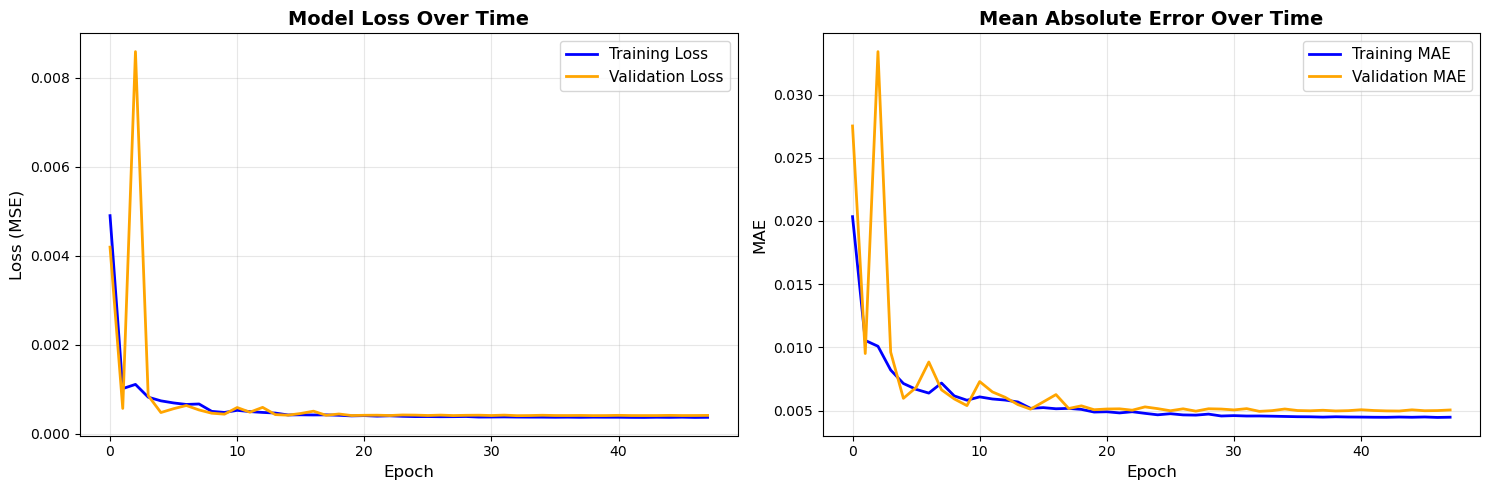

✓ Saved: training_history.png

EVALUATING ON TEST SET
113/113 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - loss: 6.0400e-04 - mae: 0.0056

Test Set Performance:
  Loss (MSE): 0.000604
  MAE: 0.005597
  RMSE: 0.024576

✓ Test metrics saved

TRAINING SUMMARY

Best Performance:
  Best epoch: 33/48
  Best validation loss: 0.000402
  Test MAE: 0.005597

✅ EXCELLENT: MAE < 0.05

TRAINING PIPELINE COMPLETE

✓ Best model: best_convlstm_model.keras
✓ Training history: training_history.json
✓ Test metrics: test_metrics.json
✓ Training plot: training_history.png


In [ ]:
# Training
print("\n" + "="*70)
print("STARTING TRAINING (GENERATOR MODE)")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nMemory-efficient mode: Data loaded batch-by-batch")
print(f"You can stop training anytime:")
print(f"  - In Jupyter: Use 'Interrupt Kernel' button (⏹️) or Kernel > Interrupt")
print(f"  - In Terminal: Press Ctrl+C")
print()

history = None  # Initialize history variable

try:
    history = model.fit(
        train_generator,  # Generator instead of X_train
        epochs=EPOCHS,
        validation_data=val_generator,  # Generator instead of X_val
        callbacks=callbacks,
        verbose=1
    )
    
    print("\n" + "="*70)
    print("TRAINING COMPLETE")
    print("="*70)
    print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total epochs trained: {len(history.history['loss'])}")
    
except KeyboardInterrupt:
    print("\n" + "="*70)
    print("TRAINING INTERRUPTED BY USER (Ctrl+C)")
    print("="*70)
    print("✓ Best model saved: best_convlstm_model.keras")
    print("\nYou can resume training by running this script again!")
    
except Exception as e:
    print("\n" + "="*70)
    print("TRAINING INTERRUPTED")
    print("="*70)
    print(f"Reason: {type(e).__name__}")
    print("✓ Best model saved: best_convlstm_model.keras")
    print("\nYou can resume training by running this script again!")

# Check if training completed at least one epoch
if history is None or len(history.history.get('loss', [])) == 0:
    print("\n⚠️  Training was stopped before completing any epochs.")
    print("✓ Model architecture saved, but no training history available.")
    print("\nTo resume training, simply run this script again.")
    print("="*70)
else:
    # Save training history
    history_dict = {
        'loss': [float(x) for x in history.history['loss']],
        'val_loss': [float(x) for x in history.history['val_loss']],
        'mae': [float(x) for x in history.history['mae']],
        'val_mae': [float(x) for x in history.history['val_mae']],
    }

    with open('training_history.json', 'w') as f:
        json.dump(history_dict, f, indent=2)

    print("\n✓ Training history saved")

# Plot training history
if history is not None and len(history.history.get('loss', [])) > 0:
    print("\n" + "="*50)
    print("GENERATING TRAINING PLOTS")
    print("="*50)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2, color='blue')
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='orange')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('Mean Absolute Error Over Time', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Saved: training_history.png")

    # Evaluate on test set (using generator)
    print("\n" + "="*50)
    print("EVALUATING ON TEST SET")
    print("="*50)

    test_generator = MemoryEfficientGenerator(
        X_path='X_test.npy',
        y_path='y_test.npy',
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_results = model.evaluate(test_generator, verbose=1)
    test_loss = test_results[0]
    test_mae = test_results[1]

    print(f"\nTest Set Performance:")
    print(f"  Loss (MSE): {test_loss:.6f}")
    print(f"  MAE: {test_mae:.6f}")
    print(f"  RMSE: {np.sqrt(test_loss):.6f}")

    test_metrics = {
        'test_loss': float(test_loss),
        'test_mae': float(test_mae),
        'test_rmse': float(np.sqrt(test_loss)),
        'final_train_loss': float(history.history['loss'][-1]),
        'final_val_loss': float(history.history['val_loss'][-1]),
        'best_val_loss': float(min(history.history['val_loss'])),
        'total_epochs': len(history.history['loss'])
    }

    with open('test_metrics.json', 'w') as f:
        json.dump(test_metrics, f, indent=2)

    print("\n✓ Test metrics saved")

    # Performance assessment
    print("\n" + "="*70)
    print("TRAINING SUMMARY")
    print("="*70)

    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])

    print(f"\nBest Performance:")
    print(f"  Best epoch: {best_epoch}/{len(history.history['loss'])}")
    print(f"  Best validation loss: {best_val_loss:.6f}")
    print(f"  Test MAE: {test_mae:.6f}")

    if test_mae < 0.05:
        print("\n✅ EXCELLENT: MAE < 0.05")
    elif test_mae < 0.10:
        print("\n✅ GOOD: MAE < 0.10")
    elif test_mae < 0.15:
        print("\n⚠️  ACCEPTABLE: MAE < 0.15")
    else:
        print("\n⚠️  NEEDS IMPROVEMENT: MAE > 0.15")

    print("\n" + "="*70)
    print("TRAINING PIPELINE COMPLETE")
    print("="*70)
    print("\n✓ Best model: best_convlstm_model.keras")
    print("✓ Training history: training_history.json")
    print("✓ Test metrics: test_metrics.json")
    print("✓ Training plot: training_history.png")
    print("="*70)

# Visualization and Flood Depth Prediction

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import json

print("="*70)
print("STEP 5: INFERENCE WITH FLOOD DEPTH ESTIMATION")
print("="*70)

# Load model
print("\n1. LOADING TRAINED MODEL...")
model = keras.models.load_model('best_convlstm_model.keras')
print("✓ Model loaded successfully")

# Load test data (memory-mapped)
print("\n2. LOADING TEST DATA...")
X_test = np.load('X_test.npy', mmap_mode='r')
y_test = np.load('y_test.npy', mmap_mode='r')
dem_norm = np.load('dem_norm.npy')

print(f"✓ Test data loaded:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")
print(f"  DEM: {dem_norm.shape}")

# Make predictions in batches (memory efficient)
print("\n3. MAKING PREDICTIONS...")
BATCH_SIZE = 2
n_samples = len(X_test)
n_batches = (n_samples + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Predicting on {n_samples} samples in {n_batches} batches...")

# Initialize prediction array
y_pred = np.zeros_like(y_test)

for i in range(n_batches):
    start_idx = i * BATCH_SIZE
    end_idx = min((i + 1) * BATCH_SIZE, n_samples)
    
    # Load batch into memory
    X_batch = np.array(X_test[start_idx:end_idx])
    
    # Predict
    y_pred_batch = model.predict(X_batch, verbose=0)
    y_pred[start_idx:end_idx] = y_pred_batch
    
    if (i + 1) % 50 == 0 or (i + 1) == n_batches:
        print(f"  Processed {end_idx}/{n_samples} samples...")

print(f"✓ Predictions complete!")
print(f"  Predictions shape: {y_pred.shape}")

STEP 5: INFERENCE WITH FLOOD DEPTH ESTIMATION

1. LOADING TRAINED MODEL...
✓ Model loaded successfully

2. LOADING TEST DATA...
✓ Test data loaded:
  X_test: (226, 12, 256, 256, 3)
  y_test: (226, 6, 256, 256, 1)
  DEM: (256, 256)

3. MAKING PREDICTIONS...
Predicting on 226 samples in 113 batches...
  Processed 100/226 samples...
  Processed 200/226 samples...
  Processed 226/226 samples...
✓ Predictions complete!
  Predictions shape: (226, 6, 256, 256, 1)


In [ ]:
print("\n" + "="*70)
print("4. CALCULATING METRICS")
print("="*70)

# Basic metrics
mse = np.mean((y_test - y_pred) ** 2)
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(mse)

# Nash-Sutcliffe Efficiency (NSE)
y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()
y_mean = np.mean(y_test_flat)

numerator = np.sum((y_test_flat - y_pred_flat) ** 2)
denominator = np.sum((y_test_flat - y_mean) ** 2)
nse = 1 - (numerator / denominator)

print(f"\nTest Set Metrics:")
print(f"  MSE:  {mse:.6f}")
print(f"  MAE:  {mae:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  NSE:  {nse:.6f}")

# Interpret NSE
print(f"\nNSE Interpretation:")
if nse > 0.9:
    print(f"  ⭐⭐⭐⭐⭐ EXCELLENT (NSE > 0.9)")
elif nse > 0.75:
    print(f"  ⭐⭐⭐⭐ VERY GOOD (NSE > 0.75)")
elif nse > 0.5:
    print(f"  ⭐⭐⭐ GOOD (NSE > 0.5)")
elif nse > 0:
    print(f"  ⭐⭐ ACCEPTABLE (NSE > 0)")
else:
    print(f"  ⭐ NEEDS IMPROVEMENT (NSE < 0)")


4. CALCULATING METRICS

Test Set Metrics:
  MSE:  0.000604
  MAE:  0.005597
  RMSE: 0.024577
  NSE:  0.940712

NSE Interpretation:
  ⭐⭐⭐⭐⭐ EXCELLENT (NSE > 0.9)


In [ ]:
print("\n" + "="*70)
print("5. FLOOD DEPTH ESTIMATION (FWDET)")
print("="*70)

def calculate_flood_depth_fwdet(river_level_grid, dem_grid, threshold=0.7):
    """
    Calculate flood depth using FWDET methodology
    
    FWDET Formula:
    Flood Depth = max(0, Water Surface Elevation - Ground Elevation)
    
    In normalized space:
    - River level > threshold indicates potential flooding
    - Depth = River level - DEM elevation (where river level > threshold)
    
    Args:
        river_level_grid: array (H, W) - predicted river level (0-1)
        dem_grid: array (H, W) - ground elevation (0-1)
        threshold: float - flooding threshold
    
    Returns:
        flood_depth: array (H, W) - flood depth in normalized units
        flood_extent: array (H, W) - binary flood map (1=flooded, 0=dry)
    """
    # Identify areas with high water level
    potential_flood = river_level_grid > threshold
    
    # Calculate water depth above ground
    # Depth = Water level - Ground elevation (only where water is high)
    flood_depth = np.where(
        potential_flood,
        np.maximum(0, river_level_grid - dem_grid),
        0
    )
    
    # Binary flood extent (1 = flooded, 0 = dry)
    flood_extent = (flood_depth > 0).astype(float)
    
    return flood_depth, flood_extent

# Define flood threshold
FLOOD_THRESHOLD = 0.7  # Adjust based on your basin characteristics

print(f"Using flood threshold: {FLOOD_THRESHOLD}")
print("Calculating flood depths for all predictions...")

# Calculate flood depths for all test samples
flood_depths_pred = np.zeros_like(y_pred)
flood_extents_pred = np.zeros_like(y_pred)

for sample_idx in range(len(y_pred)):
    for t in range(y_pred.shape[1]):  # For each timestep
        depth, extent = calculate_flood_depth_fwdet(
            y_pred[sample_idx, t, :, :, 0],
            dem_norm,
            threshold=FLOOD_THRESHOLD
        )
        flood_depths_pred[sample_idx, t, :, :, 0] = depth
        flood_extents_pred[sample_idx, t, :, :, 0] = extent

print("✓ Flood depths calculated using FWDET methodology")

# Calculate flood statistics
mean_flood_depth = np.mean(flood_depths_pred[flood_depths_pred > 0])
max_flood_depth = np.max(flood_depths_pred)
total_flooded_pixels = np.sum(flood_extents_pred)
total_pixels = flood_extents_pred.size

print(f"\nFlood Statistics:")
print(f"  Mean flood depth (where flooded): {mean_flood_depth:.4f} (normalized)")
print(f"  Maximum flood depth: {max_flood_depth:.4f} (normalized)")
print(f"  Total flooded pixels: {total_flooded_pixels:.0f}")
print(f"  Flood occurrence rate: {(total_flooded_pixels/total_pixels)*100:.2f}%")


5. FLOOD DEPTH ESTIMATION (FWDET)
Using flood threshold: 0.7
Calculating flood depths for all predictions...
✓ Flood depths calculated using FWDET methodology

Flood Statistics:
  Mean flood depth (where flooded): 0.8021 (normalized)
  Maximum flood depth: 0.9423 (normalized)
  Total flooded pixels: 226566
  Flood occurrence rate: 0.25%



6. VISUALIZING PREDICTIONS

Visualizing predictions with flood depth:
  Best prediction: sample 119, MSE = 0.000045


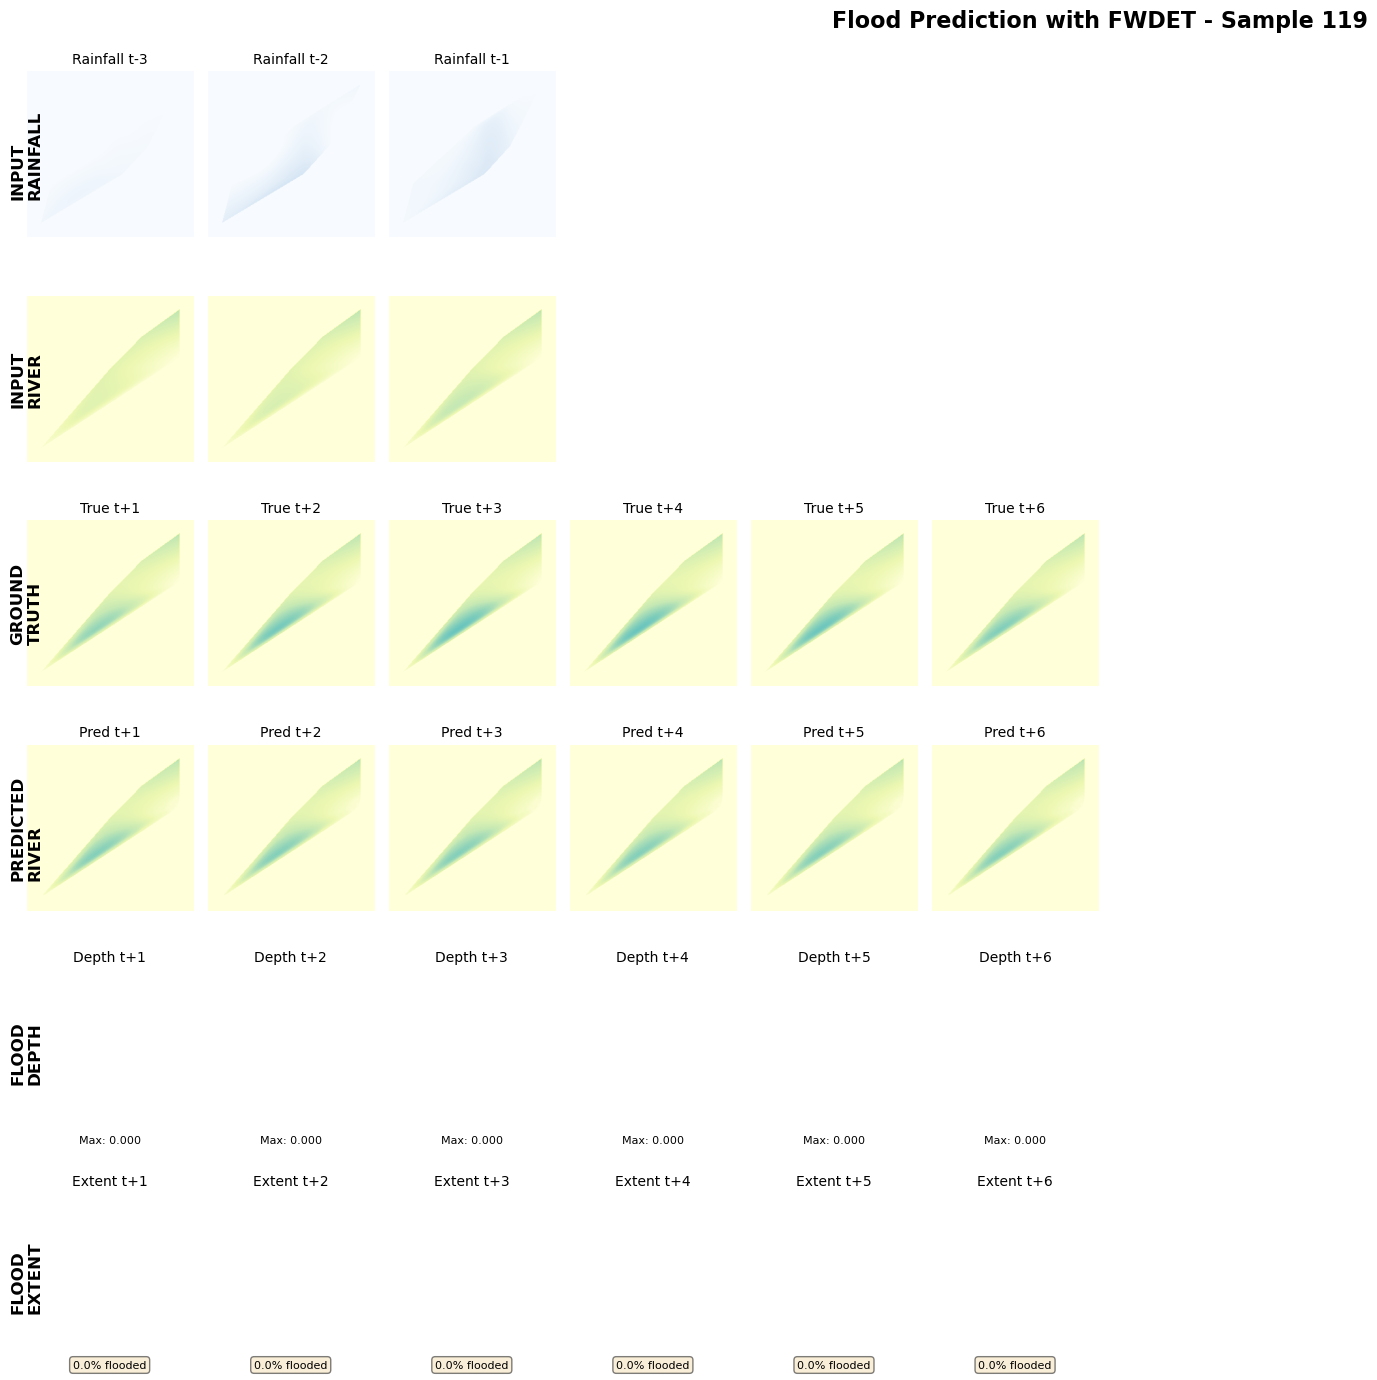

  Median prediction: sample 196, MSE = 0.000361


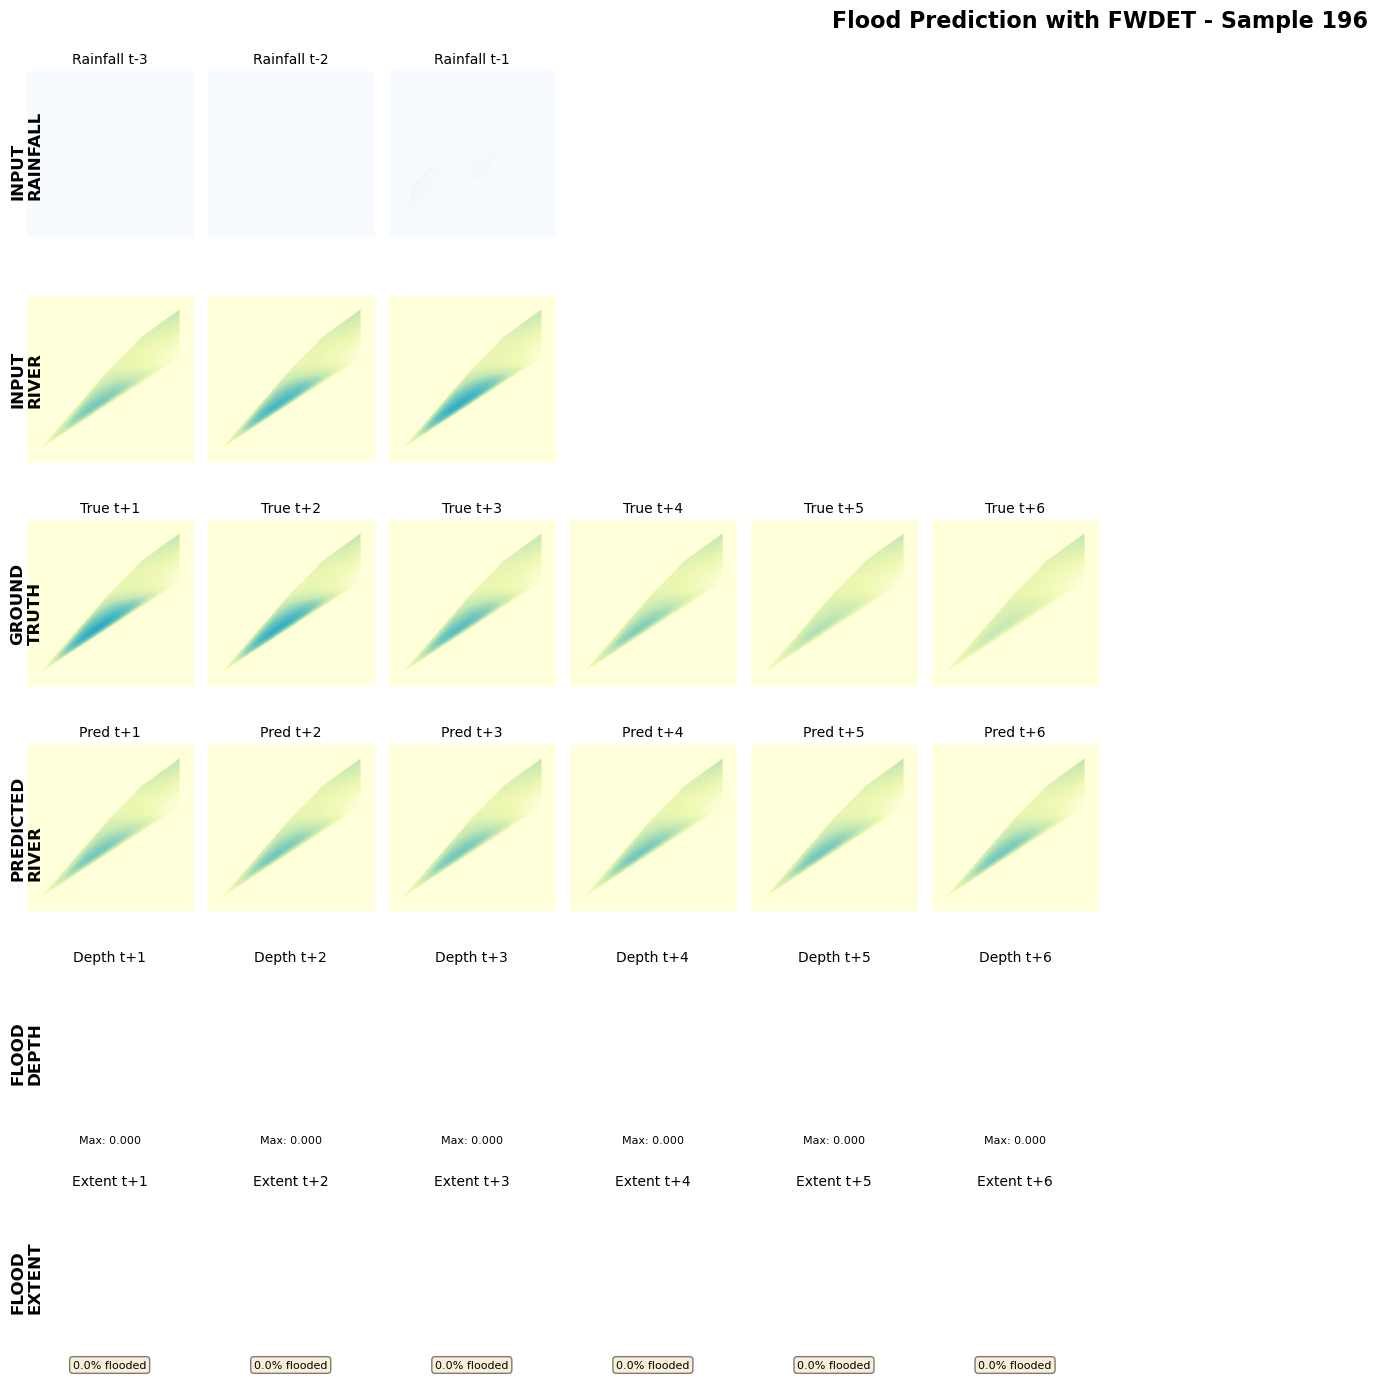

  Worst prediction: sample 103, MSE = 0.008149


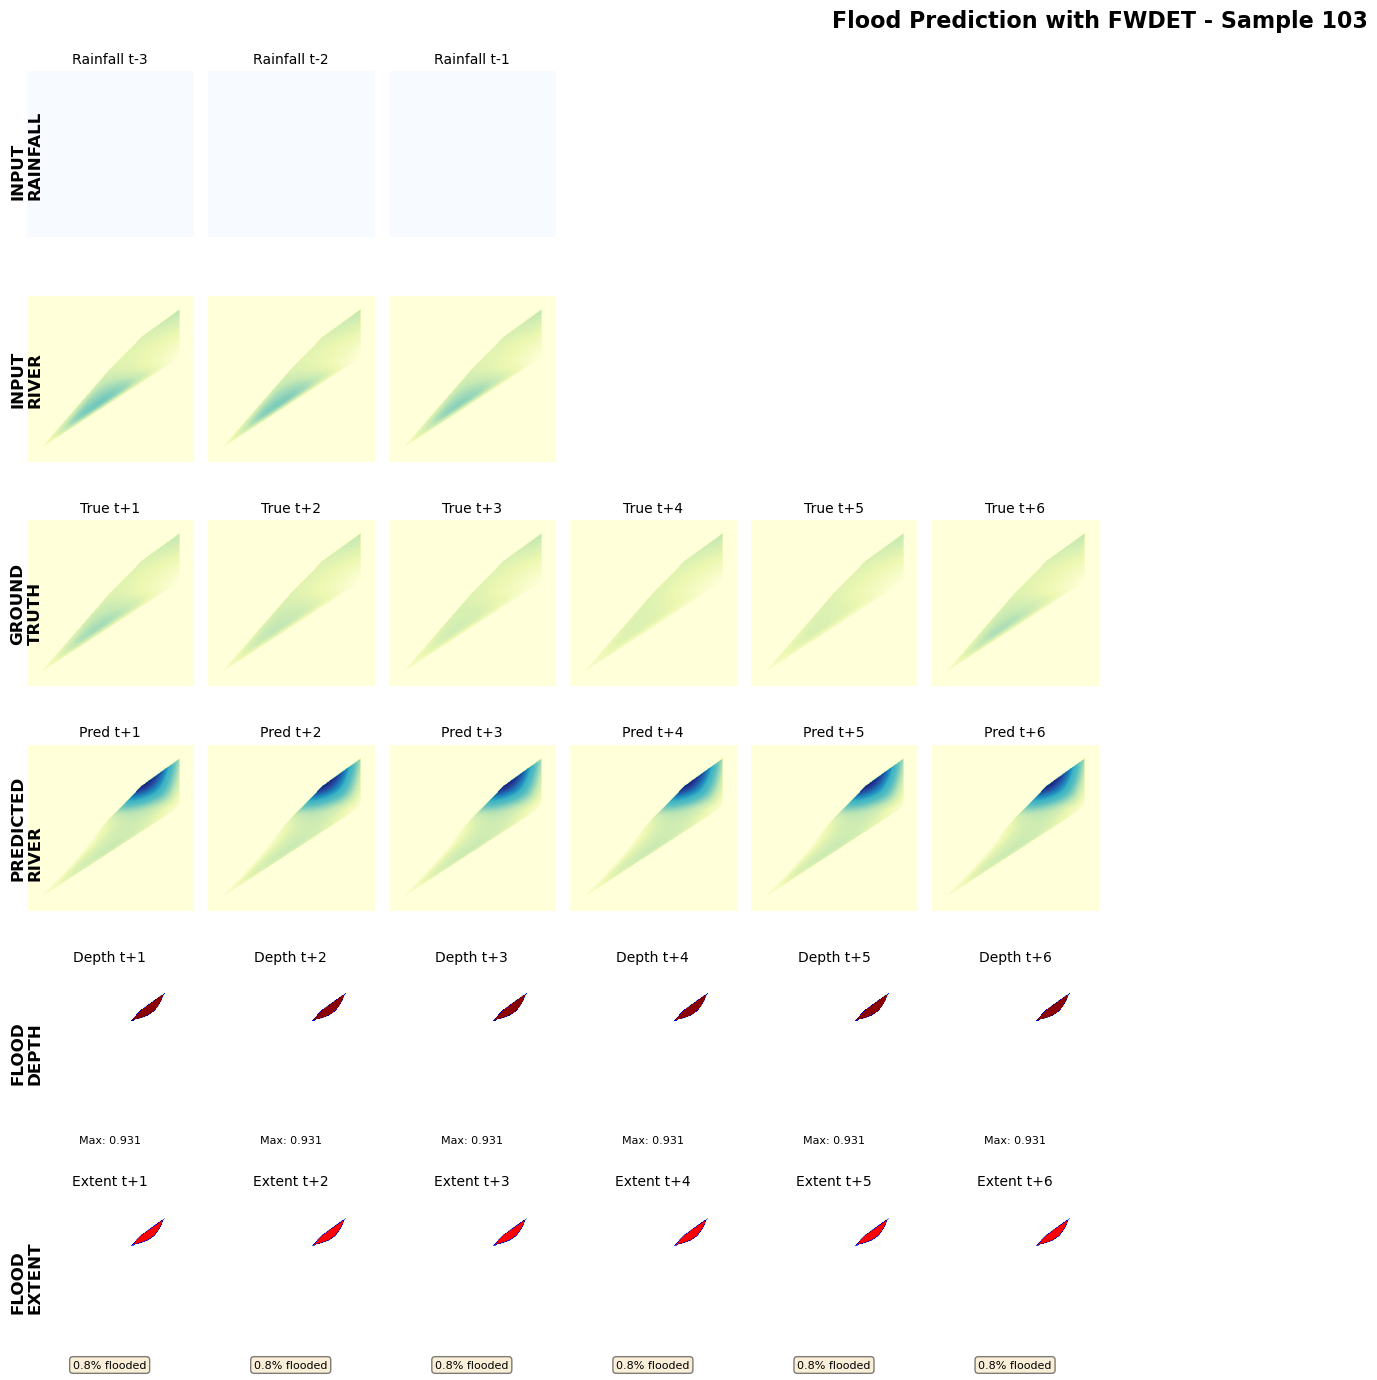

In [ ]:
print("\n" + "="*70)
print("6. VISUALIZING PREDICTIONS")
print("="*70)

def visualize_prediction_with_depth(X, y_true, y_pred, flood_depth, flood_extent, 
                                     sample_idx, dem, save_path=None):
    """
    Visualize input, predictions, and flood depth estimates
    """
    input_steps = X.shape[1]
    output_steps = y_true.shape[1]
    
    # Load sample into memory
    X_sample = np.array(X[sample_idx:sample_idx+1])[0]
    y_true_sample = np.array(y_true[sample_idx:sample_idx+1])[0]
    y_pred_sample = y_pred[sample_idx]
    flood_depth_sample = flood_depth[sample_idx]
    flood_extent_sample = flood_extent[sample_idx]
    
    fig = plt.figure(figsize=(22, 14))
    
    # Custom colormaps
    # Flood alert thresholds (normalized)
    _river_min = river_scaler.data_min_[0]
    _river_max = river_scaler.data_max_[0]
    _river_range = _river_max - _river_min if _river_max != _river_min else 1.0
    _alert_n = np.clip((1.6 - _river_min) / _river_range, 0, 1)
    _alarm_n = np.clip((2.4 - _river_min) / _river_range, 0, 1)
    _crit_n  = np.clip((4.0 - _river_min) / _river_range, 0, 1)
    
    _rl_stops = [
        (0.0,      '#2166ac'),
        (_alert_n, '#67a9cf'),
        (_alert_n, '#fdd835'),
        (_alarm_n, '#fb8c00'),
        (_crit_n,  '#d32f2f'),
        (1.0,      '#7b0000'),
    ]
    _rl_stops = [(p, c) for p, c in _rl_stops if p <= 1.0]
    if _rl_stops[-1][0] < 1.0:
        _rl_stops.append((1.0, _rl_stops[-1][1]))
    river_level_cmap = LinearSegmentedColormap.from_list('flood_levels', _rl_stops)
    
    flood_cmap = LinearSegmentedColormap.from_list(
        'flood', ['white', 'lightblue', 'blue', 'darkblue', 'red']
    )
    depth_cmap = LinearSegmentedColormap.from_list(
        ax.imshow(X_sample[t, :, :, 1], cmap=river_level_cmap, vmin=0, vmax=1)
    )
    
    max_cols = max(input_steps, output_steps)
    
    # Row 1: Input Rainfall (last 3 timesteps)
    display_steps = min(3, input_steps)
    for i in range(display_steps):
        t = input_steps - display_steps + i
        ax.imshow(y_true_sample[t, :, :, 0], cmap=river_level_cmap, vmin=0, vmax=1)
        ax.imshow(X_sample[t, :, :, 0], cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f'Rainfall t-{input_steps-t}', fontsize=10)
        ax.axis('off')
        if i == 0:
            ax.text(-0.1, 0.5, 'INPUT\nRAINFALL', transform=ax.transAxes,
                   fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # Row 2: Input River Level
    for i in range(display_steps):
        im_rl_pred = ax.imshow(y_pred_sample[t, :, :, 0], cmap=river_level_cmap, vmin=0, vmax=1)
        ax = plt.subplot(6, max_cols, max_cols + i + 1)
        ax.imshow(X_sample[t, :, :, 1], cmap='YlGnBu', vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.text(-0.1, 0.5, 'INPUT\nRIVER', transform=ax.transAxes,
                   fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # Row 3: Ground Truth River Level
    for t in range(output_steps):
        ax = plt.subplot(6, max_cols, 2 * max_cols + t + 1)
        ax.imshow(y_true_sample[t, :, :, 0], cmap='YlGnBu', vmin=0, vmax=1)
        ax.set_title(f'True t+{t+1}', fontsize=10)
        ax.axis('off')
        if t == 0:
            ax.text(-0.1, 0.5, 'GROUND\nTRUTH', transform=ax.transAxes,
                   fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # Row 4: Predicted River Level
    for t in range(output_steps):
        ax = plt.subplot(6, max_cols, 3 * max_cols + t + 1)
        ax.imshow(y_pred_sample[t, :, :, 0], cmap='YlGnBu', vmin=0, vmax=1)
        ax.set_title(f'Pred t+{t+1}', fontsize=10)
        ax.axis('off')
        if t == 0:
            ax.text(-0.1, 0.5, 'PREDICTED\nRIVER', transform=ax.transAxes,
                   fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # Row 5: Flood Depth (FWDET)
    for t in range(output_steps):
        ax = plt.subplot(6, max_cols, 4 * max_cols + t + 1)
        im = ax.imshow(flood_depth_sample[t, :, :, 0], cmap=depth_cmap, vmin=0, vmax=0.5)
        ax.set_title(f'Depth t+{t+1}', fontsize=10)
        ax.axis('off')
        if t == 0:
            ax.text(-0.1, 0.5, 'FLOOD\nDEPTH', transform=ax.transAxes,
                   fontsize=12, fontweight='bold', va='center', rotation=90)
        
        # Add max depth text
        max_depth = flood_depth_sample[t, :, :, 0].max()
        ax.text(0.5, -0.05, f'Max: {max_depth:.3f}',
               transform=ax.transAxes, ha='center', fontsize=8)
    
    # Row 6: Flood Extent (Binary)
    for t in range(output_steps):
        ax = plt.subplot(6, max_cols, 5 * max_cols + t + 1)
        ax.imshow(flood_extent_sample[t, :, :, 0], cmap=flood_cmap, vmin=0, vmax=1)
        ax.set_title(f'Extent t+{t+1}', fontsize=10)
        ax.axis('off')
        if t == 0:
            ax.text(-0.1, 0.5, 'FLOOD\nEXTENT', transform=ax.transAxes,
                   fontsize=12, fontweight='bold', va='center', rotation=90)
        
        # Add percentage flooded
        flooded_pct = (np.sum(flood_extent_sample[t, :, :, 0]) / 
                       flood_extent_sample[t, :, :, 0].size) * 100
        ax.text(0.5, -0.05, f'{flooded_pct:.1f}% flooded',
               transform=ax.transAxes, ha='center', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'Flood Prediction with FWDET - Sample {sample_idx}', 
                 fontsize=16, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0, 0.92, 0.98])
    
    # Add river level colorbar with alert thresholds
    cbar_ax = fig.add_axes([0.93, 0.45, 0.012, 0.35])
    cbar = fig.colorbar(im_rl_pred, cax=cbar_ax)
    cbar.set_label('River Level', fontsize=9)
    for _lv, _lb, _lc in [(_alert_n, 'Alert 1.6m', '#fdd835'),
                            (_alarm_n, 'Alarm 2.4m', '#fb8c00'),
                            (_crit_n, 'Critical 4m', '#d32f2f')]:
        if 0 < _lv <= 1:
            cbar.ax.axhline(y=_lv, color='black', linewidth=1.2, linestyle='--')
            cbar.ax.text(1.4, _lv, _lb, transform=cbar.ax.get_yaxis_transform(),
                        fontsize=7, va='center', fontweight='bold', color=_lc)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Visualize best, median, worst predictions                                 'prediction_worst_with_depth.png')

sample_mse = np.mean((y_test - y_pred) ** 2, axis=(1, 2, 3, 4))                                 flood_extents_pred, worst_idx, dem_norm,

best_idx = np.argmin(sample_mse)visualize_prediction_with_depth(X_test, y_test, y_pred, flood_depths_pred,

worst_idx = np.argmax(sample_mse)print(f"  Worst prediction: sample {worst_idx}, MSE = {sample_mse[worst_idx]:.6f}")

median_idx = np.argsort(sample_mse)[len(sample_mse) // 2]

                                 'prediction_median_with_depth.png')

print(f"\nVisualizing predictions with flood depth:")                                 flood_extents_pred, median_idx, dem_norm,

print(f"  Best prediction: sample {best_idx}, MSE = {sample_mse[best_idx]:.6f}")visualize_prediction_with_depth(X_test, y_test, y_pred, flood_depths_pred,

visualize_prediction_with_depth(X_test, y_test, y_pred, flood_depths_pred, print(f"  Median prediction: sample {median_idx}, MSE = {sample_mse[median_idx]:.6f}")

                                 flood_extents_pred, best_idx, dem_norm,
                                 'prediction_best_with_depth.png')


7. ERROR ANALYSIS

Error per future timestep:
Hour | MAE      | RMSE
-----|----------|----------
 +1  | 0.006068 | 0.025898
 +2  | 0.005391 | 0.023640
 +3  | 0.004545 | 0.020393
 +4  | 0.004708 | 0.022247
 +5  | 0.005801 | 0.025233
 +6  | 0.007068 | 0.029102


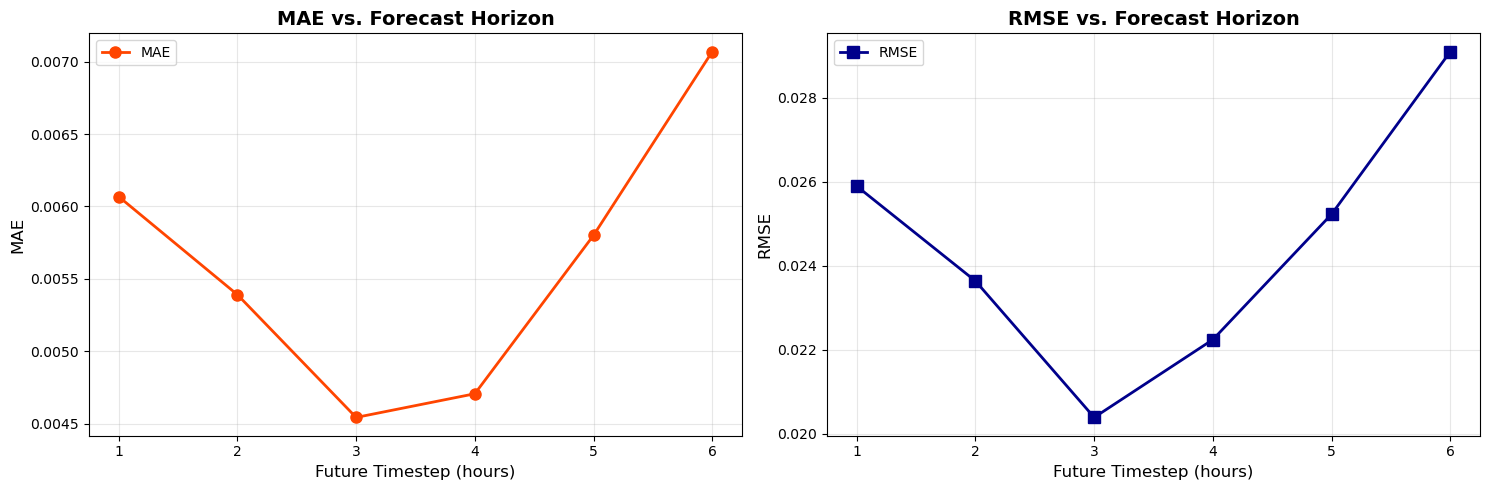

✓ Saved: temporal_error_analysis.png

Calculating spatial error distribution...


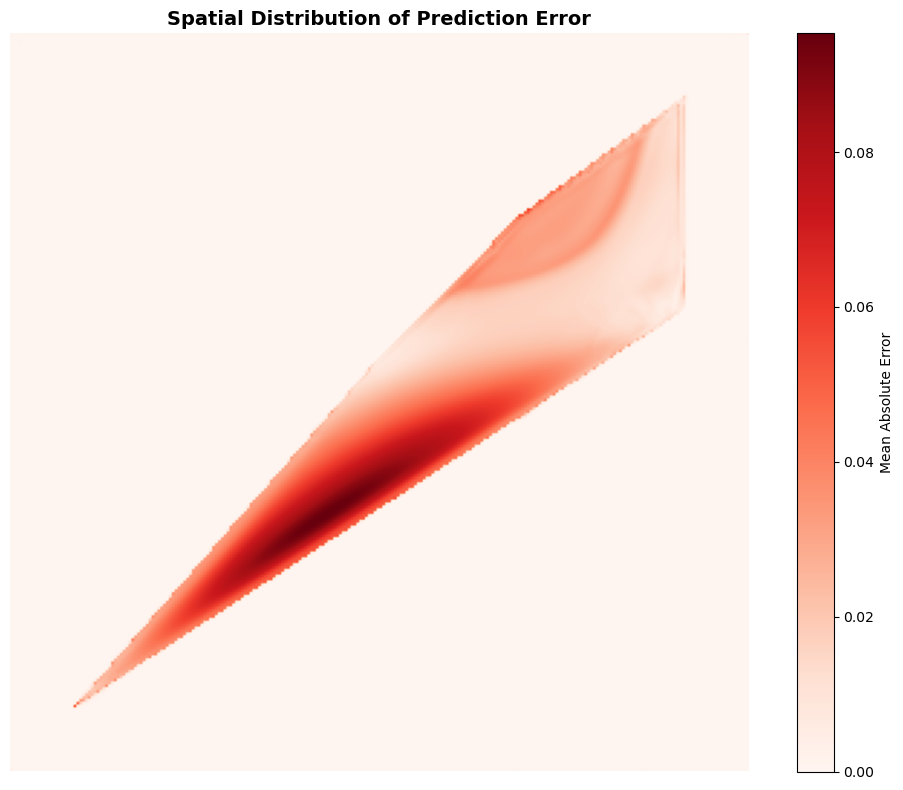

✓ Saved: spatial_error.png

Generating prediction scatter plot...


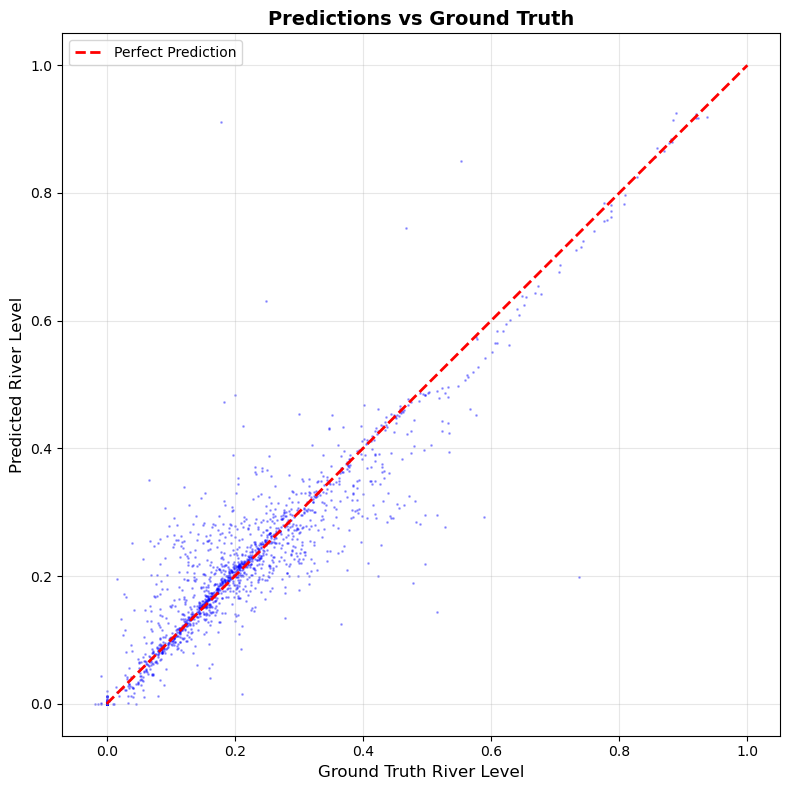

✓ Saved: prediction_scatter.png


In [ ]:
print("\n" + "="*70)
print("7. ERROR ANALYSIS")
print("="*70)

# Temporal error
temporal_mae = np.mean(np.abs(y_test - y_pred), axis=(0, 2, 3, 4))
temporal_rmse = np.sqrt(np.mean((y_test - y_pred) ** 2, axis=(0, 2, 3, 4)))

print("\nError per future timestep:")
print("Hour | MAE      | RMSE")
print("-----|----------|----------")
for t in range(len(temporal_mae)):
    print(f" +{t+1}  | {temporal_mae[t]:.6f} | {temporal_rmse[t]:.6f}")

# Plot temporal error
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE vs horizon
axes[0].plot(range(1, len(temporal_mae) + 1), temporal_mae, 
         marker='o', linewidth=2, markersize=8, color='orangered', label='MAE')
axes[0].set_xlabel('Future Timestep (hours)', fontsize=12)
axes[0].set_ylabel('MAE', fontsize=12)
axes[0].set_title('MAE vs. Forecast Horizon', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(range(1, len(temporal_mae) + 1))

# RMSE vs horizon
axes[1].plot(range(1, len(temporal_rmse) + 1), temporal_rmse,
         marker='s', linewidth=2, markersize=8, color='darkblue', label='RMSE')
axes[1].set_xlabel('Future Timestep (hours)', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('RMSE vs. Forecast Horizon', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(range(1, len(temporal_rmse) + 1))

plt.tight_layout()
plt.savefig('temporal_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: temporal_error_analysis.png")

# Spatial error heatmap
print("\nCalculating spatial error distribution...")
mean_error = np.mean(np.abs(y_test - y_pred), axis=(0, 1, 4))

plt.figure(figsize=(10, 8))
im = plt.imshow(mean_error, cmap='Reds')
plt.colorbar(im, label='Mean Absolute Error')
plt.title('Spatial Distribution of Prediction Error', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('spatial_error.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: spatial_error.png")

# Scatter plot
print("\nGenerating prediction scatter plot...")
sample_indices = np.random.choice(len(y_test_flat), size=min(10000, len(y_test_flat)), replace=False)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_flat[sample_indices], y_pred_flat[sample_indices], 
            alpha=0.3, s=1, c='blue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Ground Truth River Level', fontsize=12)
plt.ylabel('Predicted River Level', fontsize=12)
plt.title('Predictions vs Ground Truth', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: prediction_scatter.png")

In [ ]:
print("\n" + "="*70)
print("8. SAVING METRICS")
print("="*70)

# Comprehensive metrics dictionary
comprehensive_metrics = {
    'test_mse': float(mse),
    'test_mae': float(mae),
    'test_rmse': float(rmse),
    'test_nse': float(nse),
    'temporal_mae': [float(x) for x in temporal_mae],
    'temporal_rmse': [float(x) for x in temporal_rmse],
    'flood_statistics': {
        'mean_depth_normalized': float(mean_flood_depth),
        'max_depth_normalized': float(max_flood_depth),
        'flood_occurrence_rate_percent': float((total_flooded_pixels/total_pixels)*100),
        'flood_threshold_used': float(FLOOD_THRESHOLD)
    }
}

with open('comprehensive_metrics.json', 'w') as f:
    json.dump(comprehensive_metrics, f, indent=2)

print("✓ Saved: comprehensive_metrics.json")


8. SAVING METRICS
✓ Saved: comprehensive_metrics.json


In [ ]:
print("\n" + "="*70)
print("INFERENCE & ANALYSIS COMPLETE")
print("="*70)

print("\n📊 FINAL METRICS:")
print(f"  MSE:  {mse:.6f}")
print(f"  MAE:  {mae:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  NSE:  {nse:.6f}")

print("\n🌊 FLOOD DEPTH ANALYSIS (FWDET):")
print(f"  Mean depth (flooded areas): {mean_flood_depth:.4f}")
print(f"  Maximum depth: {max_flood_depth:.4f}")
print(f"  Flood occurrence: {(total_flooded_pixels/total_pixels)*100:.2f}%")

print("\n📁 GENERATED FILES:")
print("  - prediction_best_with_depth.png")
print("  - prediction_median_with_depth.png")
print("  - prediction_worst_with_depth.png")
print("  - temporal_error_analysis.png")
print("  - spatial_error.png")
print("  - prediction_scatter.png")
print("  - comprehensive_metrics.json")

print("\n➡️  Next step: Run Step 6 - Real-time Prediction System")
print("="*70)


INFERENCE & ANALYSIS COMPLETE

📊 FINAL METRICS:
  MSE:  0.000604
  MAE:  0.005597
  RMSE: 0.024577
  NSE:  0.940712

🌊 FLOOD DEPTH ANALYSIS (FWDET):
  Mean depth (flooded areas): 0.8021
  Maximum depth: 0.9423
  Flood occurrence: 0.25%

📁 GENERATED FILES:
  - prediction_best_with_depth.png
  - prediction_median_with_depth.png
  - prediction_worst_with_depth.png
  - temporal_error_analysis.png
  - spatial_error.png
  - prediction_scatter.png
  - comprehensive_metrics.json

➡️  Next step: Run Step 6 - Real-time Prediction System
